In [569]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [570]:
online = pd.read_csv("eeg_LSL_gpype2back_test.csv")
online

,Time,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08,Ch09,Ch10,Ch11,Ch12,Ch13
0,1.693272e+06,199999.968750,199999.96875,199999.96875,199999.96875,73926.976562,199999.968750,199999.96875,1097.605103,1.204737e+06,4.072512e+08,9.742852e+07,1.017940e+08,17.890985
1,1.693272e+06,199999.968750,199999.96875,199999.96875,199999.96875,74181.585938,199999.968750,199999.96875,1958.274780,3.834840e+06,3.950912e+08,9.451942e+07,1.017940e+08,18.089228
2,1.693272e+06,199999.968750,199999.96875,199999.96875,199999.96875,73877.859375,199999.968750,199999.96875,2742.082764,7.519018e+06,3.793589e+08,9.075571e+07,1.017940e+08,18.253036
3,1.693272e+06,199999.968750,199999.96875,199999.96875,199999.96875,73507.687500,199999.968750,199999.96875,3455.947998,1.194358e+07,3.603122e+08,8.619908e+07,8.619908e+07,18.382336
4,1.693272e+06,199999.968750,199999.96875,199999.96875,199999.96875,73673.351562,199999.968750,199999.96875,4107.472656,1.687133e+07,3.384560e+08,8.097033e+07,8.619908e+07,18.479101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16041,1.693337e+06,134414.203125,199999.96875,199999.96875,199999.96875,-6958.413086,134467.593750,199999.96875,-2.221680,4.935863e+00,8.398184e+00,1.454111e+00,1.444730e+00,-259.693542
16042,1.693337e+06,134332.843750,199999.96875,199999.96875,199999.96875,-6697.011719,134526.875000,199999.96875,-2.914265,8.492943e+00,8.330305e+00,1.437872e+00,1.444730e+00,-300.667664
16043,1.693337e+06,134519.375000,199999.96875,199999.96875,199999.96875,-6741.213867,134620.250000,199999.96875,-3.594482,1.292030e+01,8.358971e+00,1.444730e+00,1.444730e+00,-309.641937
16044,1.693337e+06,0.000000,0.00000,0.00000,0.00000,0.000000,0.000000,0.00000,-4.252551,1.808419e+01,8.505150e+00,1.479701e+00,1.444730e+00,-267.596771


In [571]:
# import pandas as pd
# import numpy as np

# arrow = online[online['Ch14'] == 38].copy()
# filtered = []
# last_time = -np.inf

# for _, row in arrow.iterrows():
#     t = row['Time']
#     if t - last_time >= 5.0:   # keep only if greater than 5 seconds apart
#         filtered.append(row)
#         last_time = t

# filtered_arrow = pd.DataFrame(filtered)

# # Step 3: extract channel 8 values
# channel_8_eeg = np.array(filtered_arrow['Ch14'])

# lifu_on_ts = np.array(filtered_arrow['Time'])
# lifu_on_ts

In [572]:
markers_df = pd.read_csv("lifu_markers_1_2back_test.csv")
# calibration_complete =markers_df[markers_df["marker"] == "START_EXPERIMENT_RECEIVED"].iloc[-1]
# calibration_complete = calibration_complete["LSL_timestamp"]
markers_df_on = markers_df[markers_df["marker"] =="LIFU_ON"]
markers_df

,Time,marker,LSL_timestamp
0,3.236809,collecting_baseline,1.693274e+06
1,3.258948,collecting_baseline,1.693274e+06
2,3.309343,collecting_baseline,1.693274e+06
3,3.337800,collecting_baseline,1.693274e+06
4,3.393953,collecting_baseline,1.693274e+06
...,...,...,...
207,48.304111,LIFU_ON,1.693319e+06
208,53.629745,LIFU_OFF,1.693325e+06
209,55.592549,LIFU_ON,1.693326e+06
210,60.915801,LIFU_OFF,1.693332e+06


In [573]:
lifu_on = markers_df[markers_df["marker"]=="LIFU_ON"].copy()
lifu_on_timestamp = lifu_on["LSL_timestamp"]
lifu_on_timestamp = np.array(lifu_on_timestamp)
lifu_on_timestamp

array([1693298.1439491, 1693305.1699361, 1693312.1747948, 1693319.1889808,
       1693326.4774191, 1693335.987696 ])

In [581]:
import numpy as np

windows_df = []
N = 2000   # number of frames per window
half = N // 2

time_array = online['Time'].to_numpy()

for ts in lifu_on_timestamp:
    # find closest frame index
    idx = np.argmin(np.abs(time_array - ts))

    # frame-based window
    start = max(idx - half, 0)
    end   = min(idx + half, len(online))

    window = online.iloc[start:end].reset_index(drop=True)
    windows_df.append(window)
windows_df = windows_df[:-1]
windows_df[4]

,Time,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08,Ch09,Ch10,Ch11,Ch12,Ch13
0,1.693322e+06,44739.937500,199999.96875,199999.96875,199999.96875,344.347992,44675.281250,199999.96875,-5.481994,30.052256,12.190956,2.361473,2.408185,-23.299997
1,1.693322e+06,44014.605469,199999.96875,199999.96875,199999.96875,345.969238,43970.113281,199999.96875,-5.117704,26.190893,12.085721,2.336297,2.408185,-37.393433
2,1.693322e+06,43546.031250,199999.96875,199999.96875,199999.96875,353.312500,43524.531250,199999.96875,-4.571856,20.901871,11.953601,2.304689,2.408185,0.690545
3,1.693322e+06,44114.167969,199999.96875,199999.96875,199999.96875,348.568024,44083.812500,199999.96875,-3.847035,14.799680,11.788571,2.265208,2.408185,37.766560
4,1.693322e+06,44690.925781,199999.96875,199999.96875,199999.96875,349.903168,44641.449219,199999.96875,-2.951763,8.712906,11.596596,2.219281,2.408185,22.205425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1.693330e+06,42057.250000,199999.96875,199999.96875,199999.96875,350.570709,42020.019531,199999.96875,-24.252666,588.191772,1245.425171,297.393555,301.418365,37.463379
1996,1.693330e+06,41739.492188,199999.96875,199999.96875,199999.96875,345.897705,41686.750000,199999.96875,-26.925488,724.981812,1258.527344,300.528076,301.418365,22.007519
1997,1.693330e+06,41246.207031,199999.96875,199999.96875,199999.96875,349.450134,41207.125000,199999.96875,-28.863312,833.090698,1270.653931,303.429138,305.509918,-23.120785
1998,1.693330e+06,41424.250000,199999.96875,199999.96875,199999.96875,355.815918,41400.742188,199999.96875,-30.058924,903.538879,1279.351318,305.509918,305.509918,-36.809296


In [582]:
channel_8 = windows_df[4]

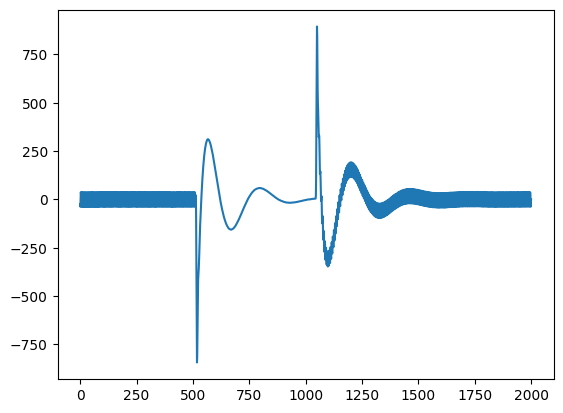

In [583]:
plt.plot(channel_8['Ch13'])

In [584]:
import pandas as pd

stacked = []

for i, w in enumerate(windows_df):
    w2 = w.copy()
    w2["window_id"] = i
    stacked.append(w2)

all_windows = pd.concat(stacked, ignore_index=True)
all_windows.to_csv("all_windows.csv", index=False)


In [585]:
windows = np.array([w.to_numpy() for w in windows_df])

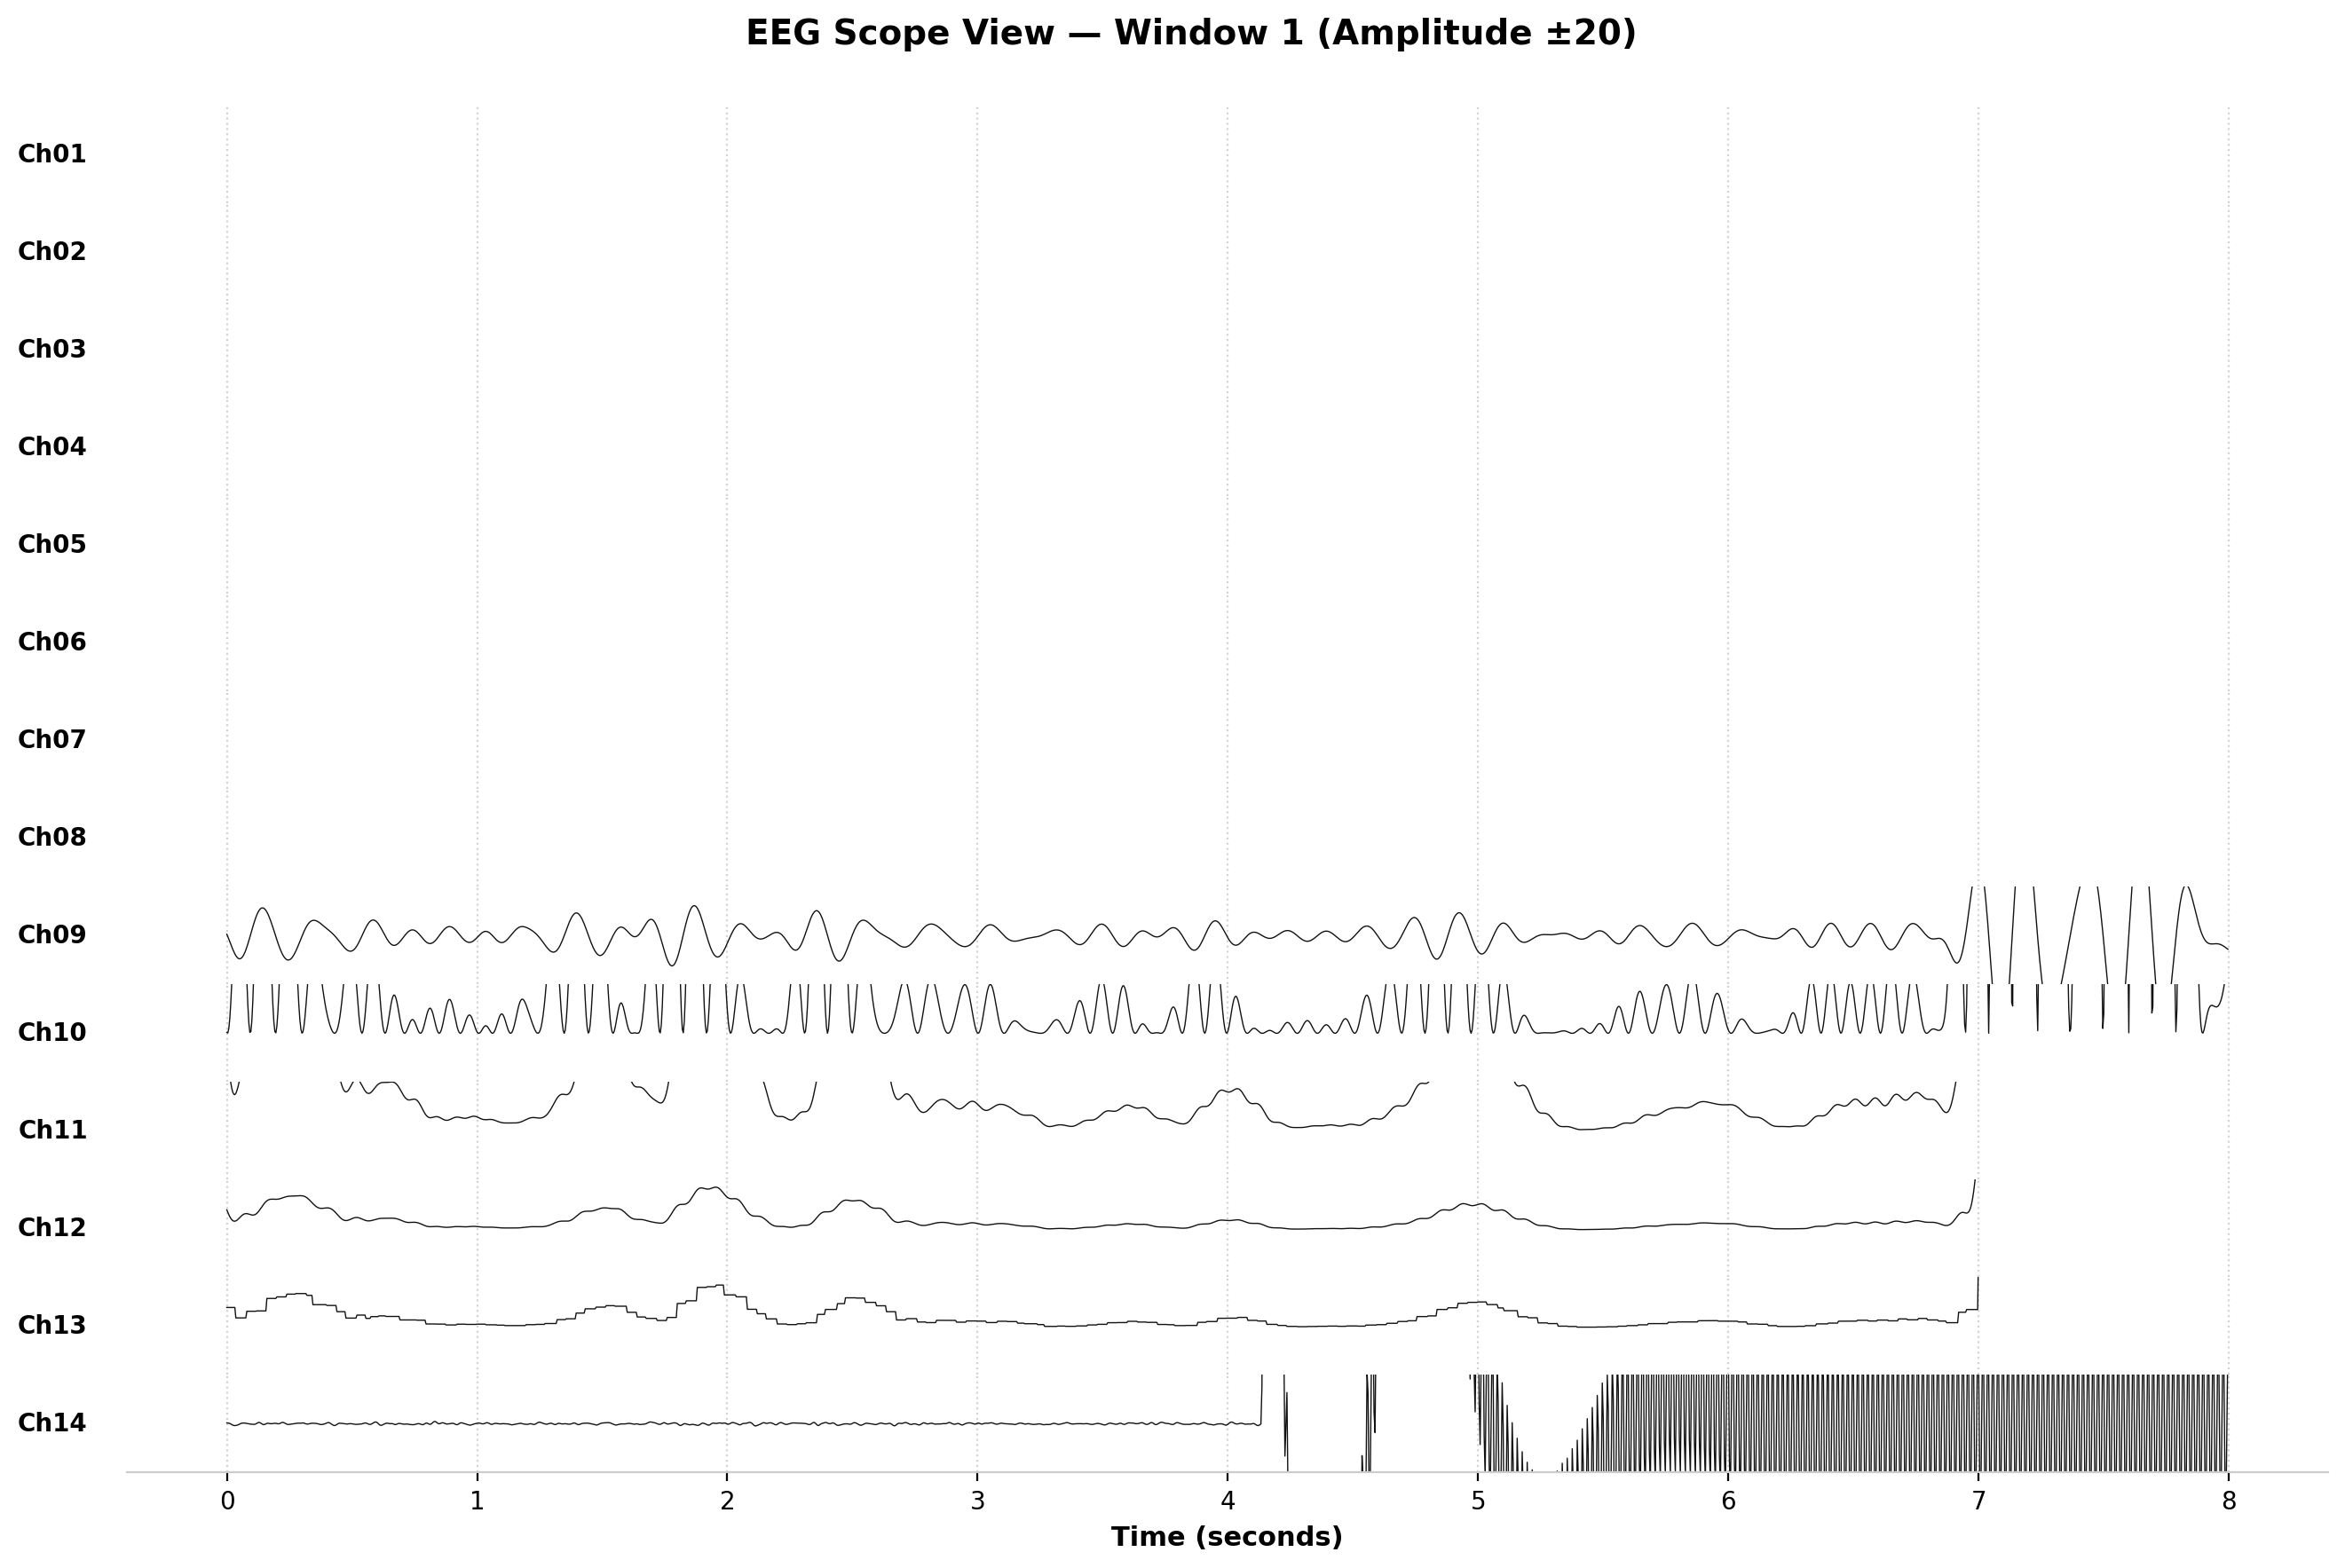

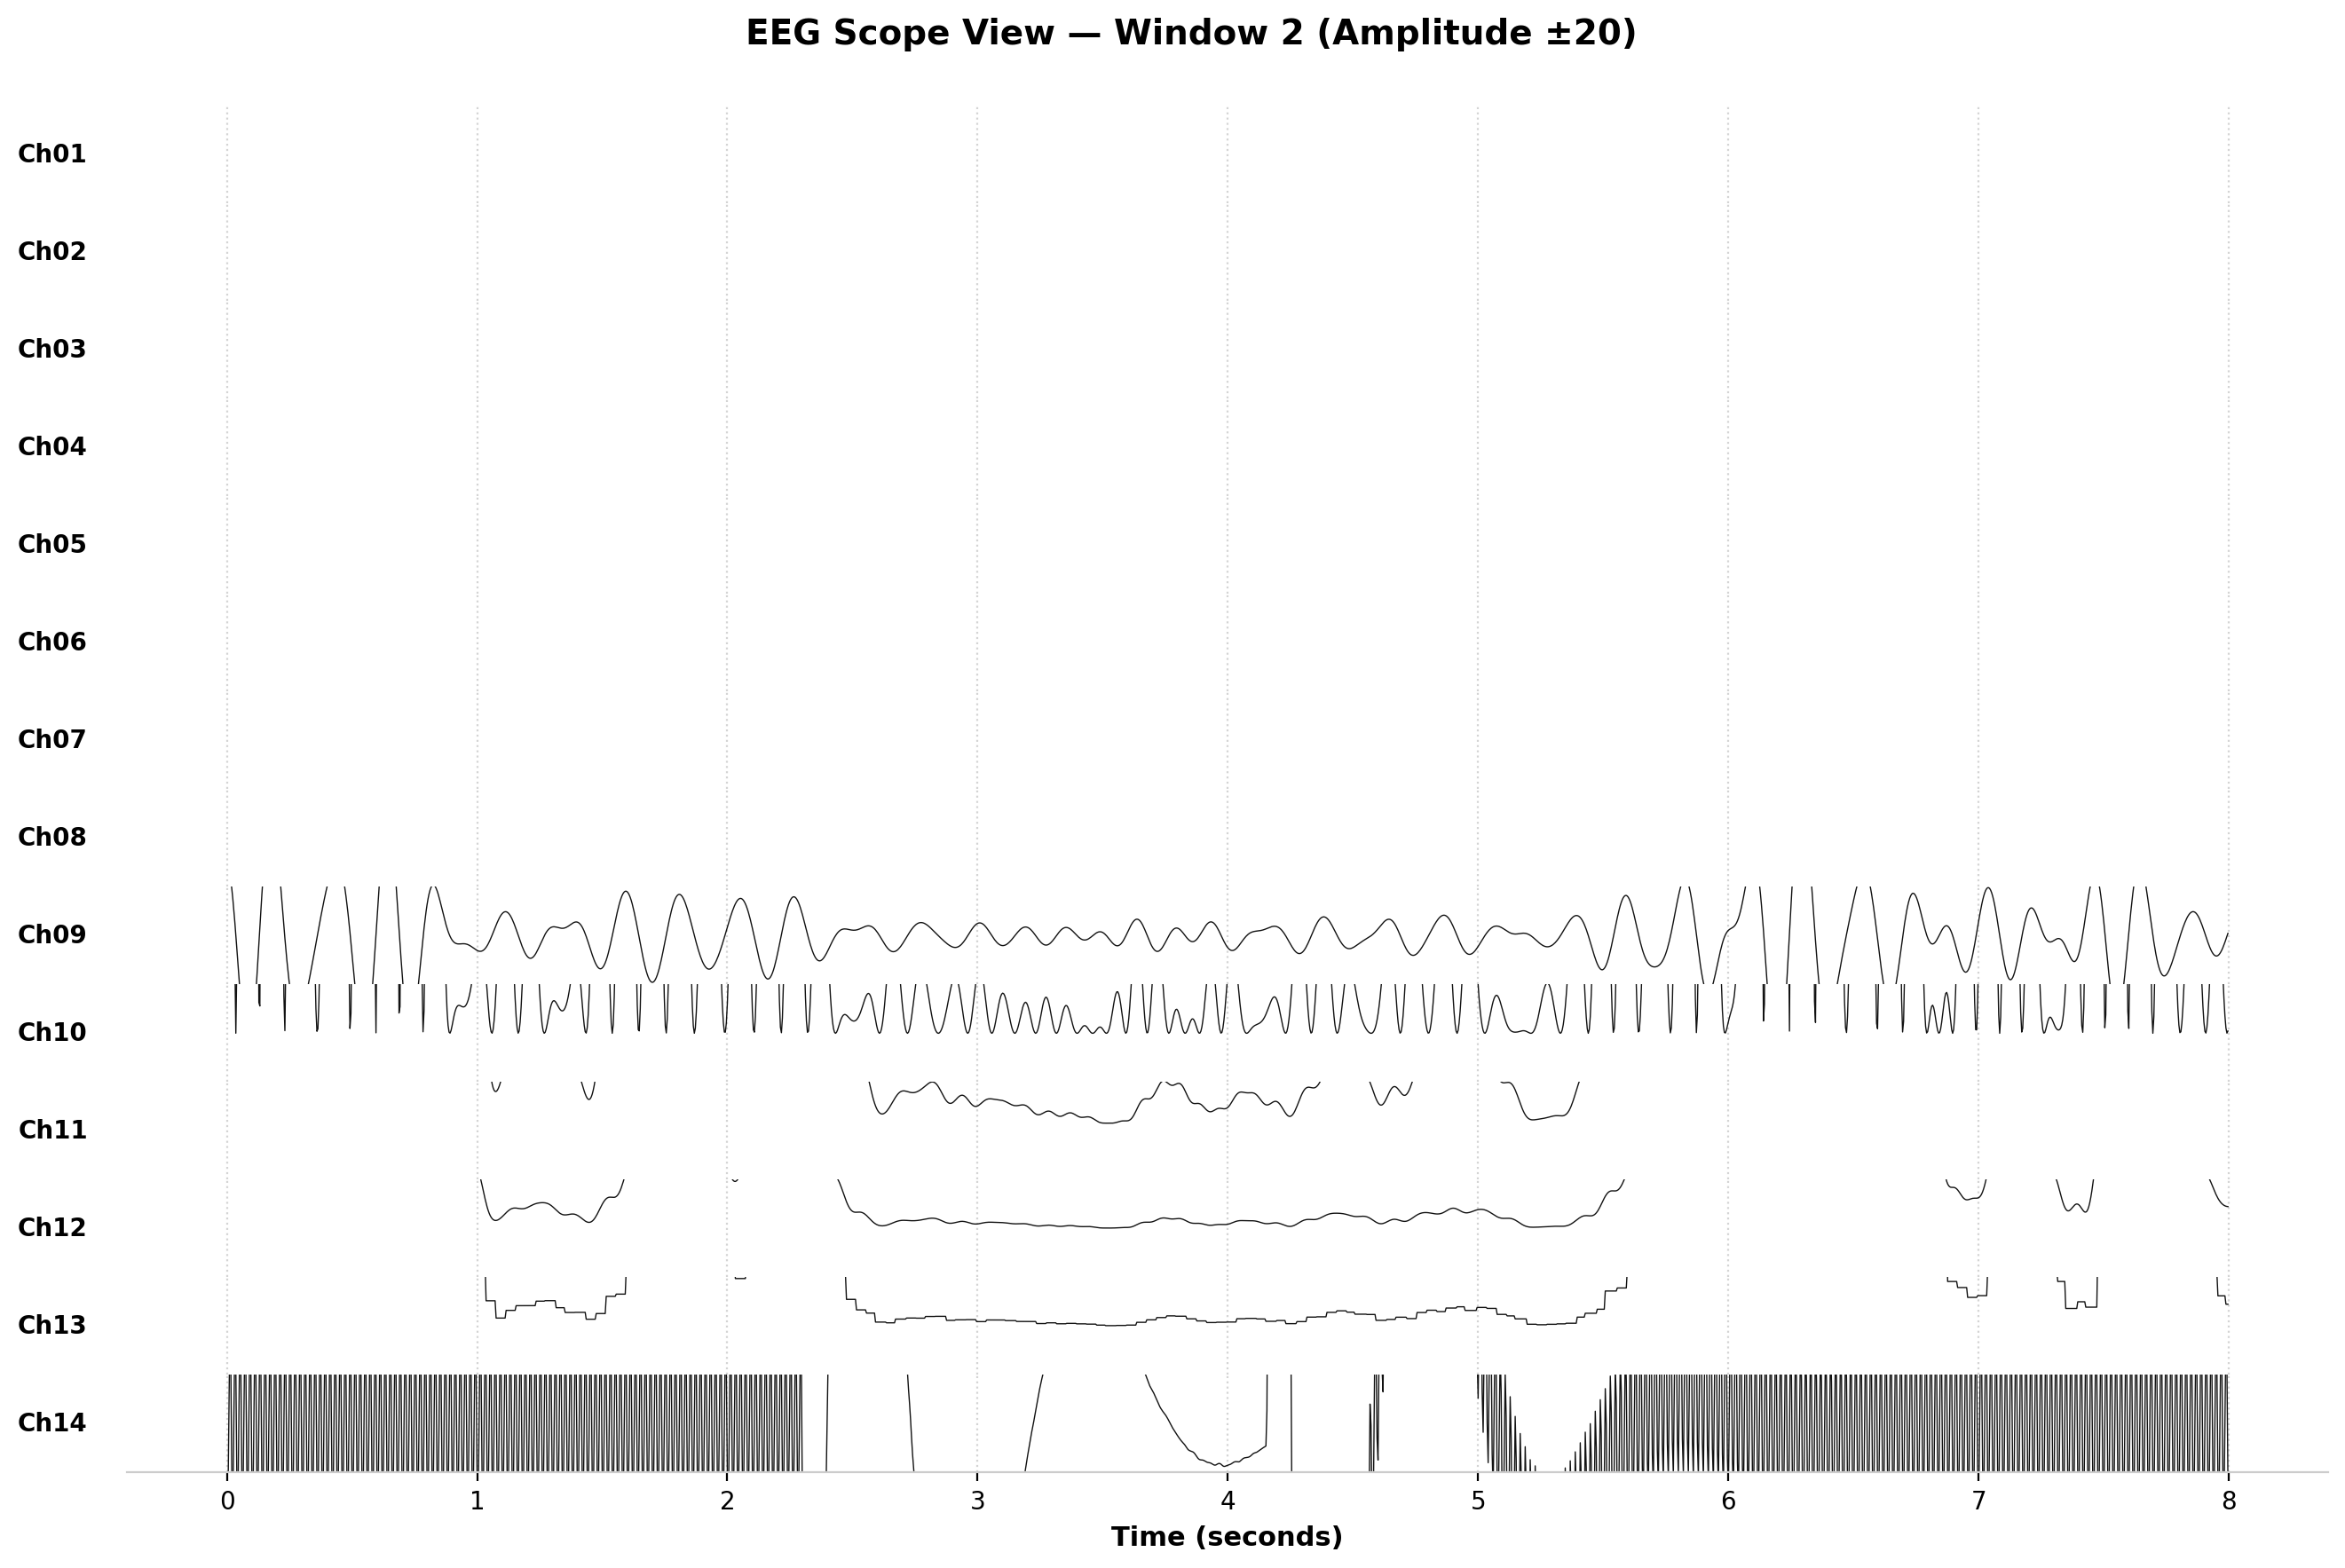

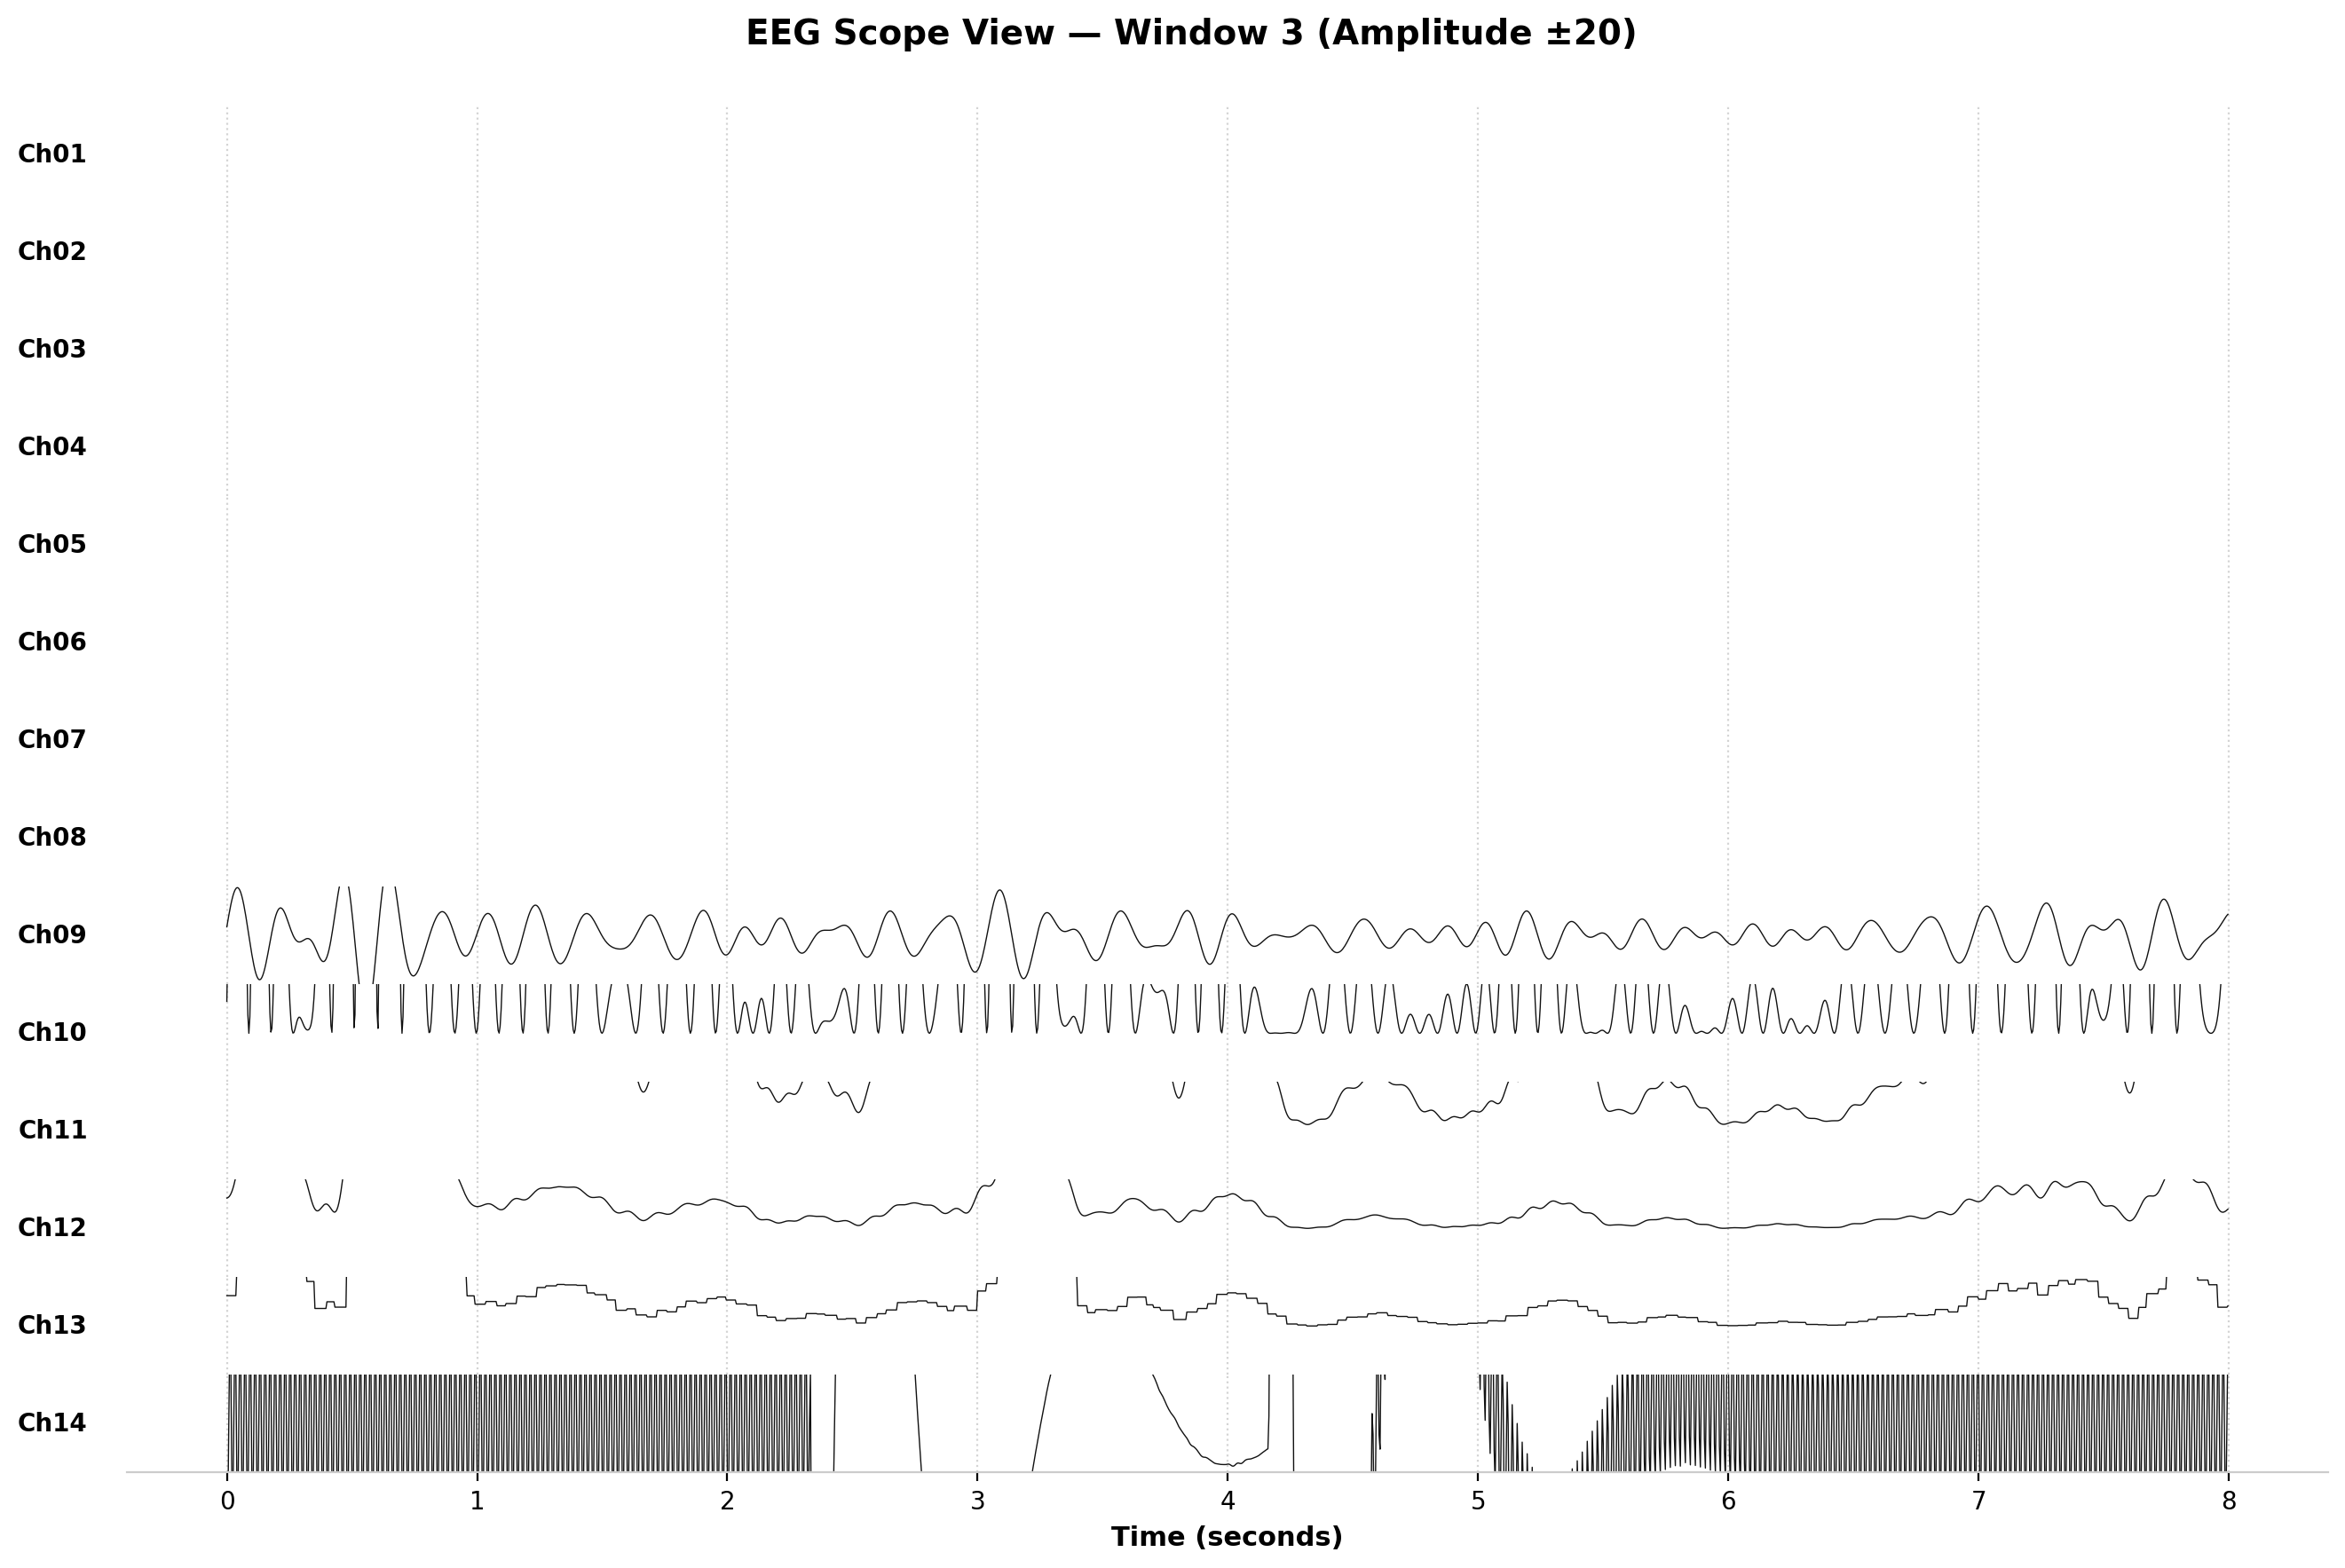

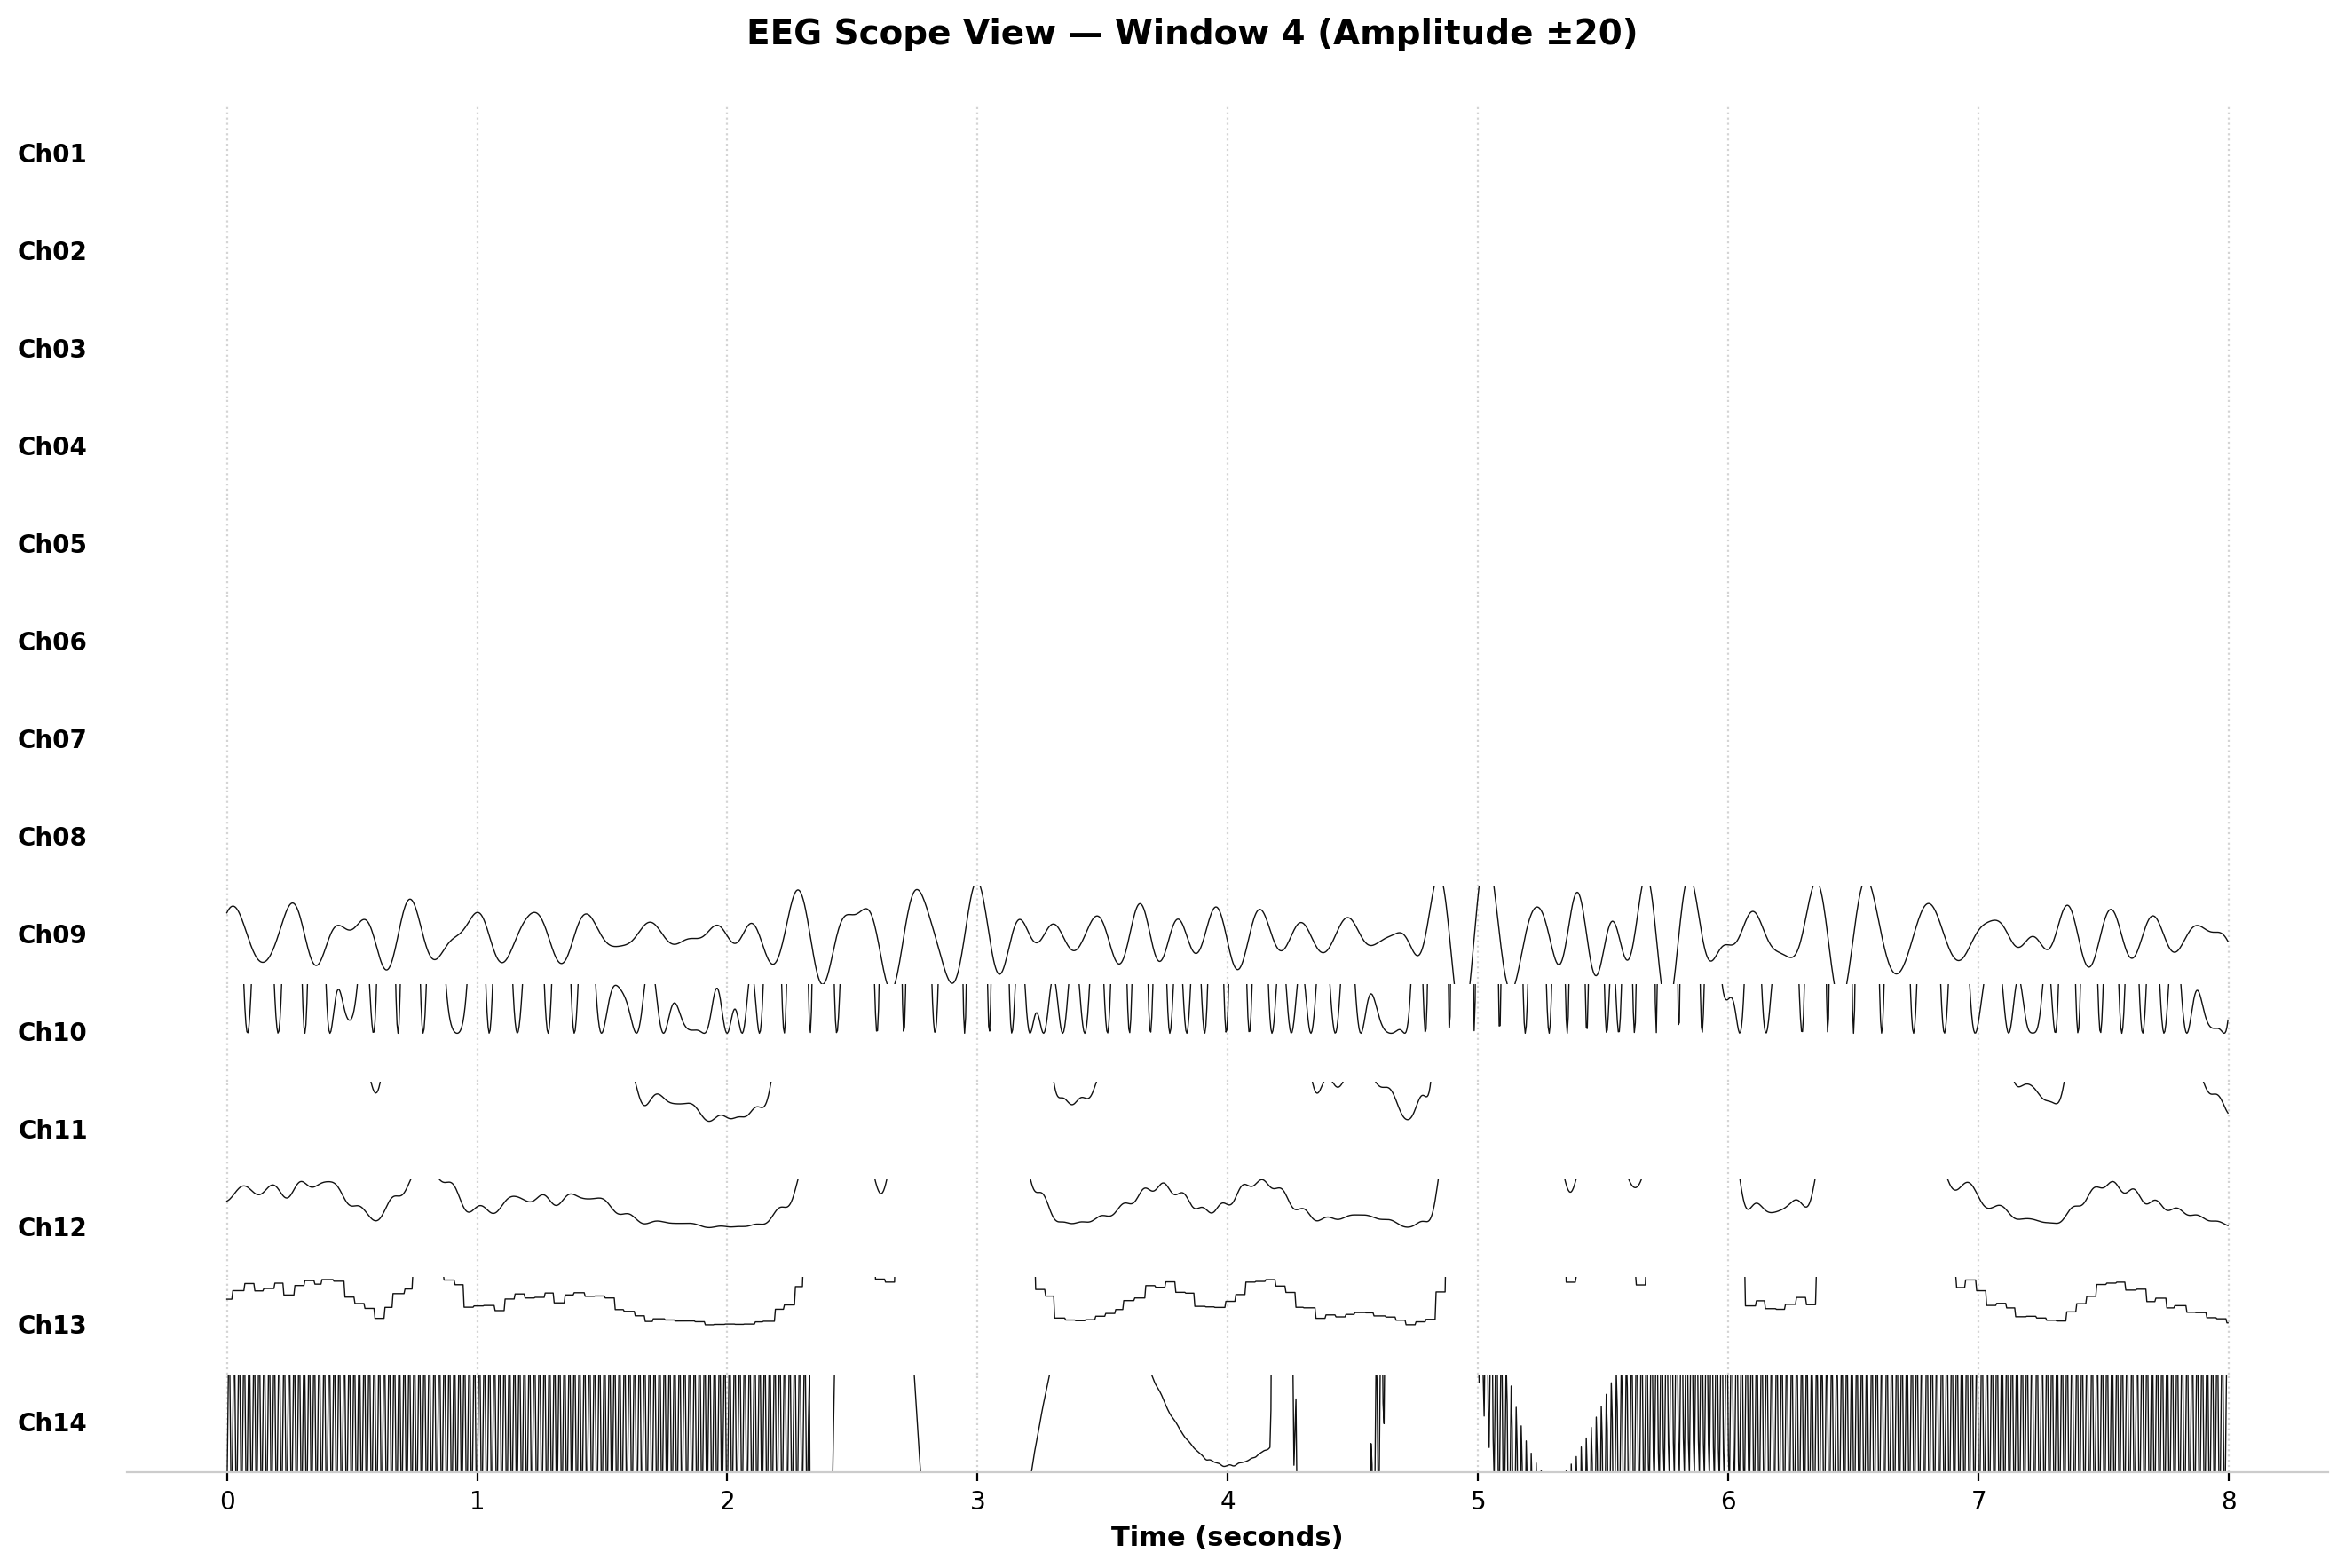

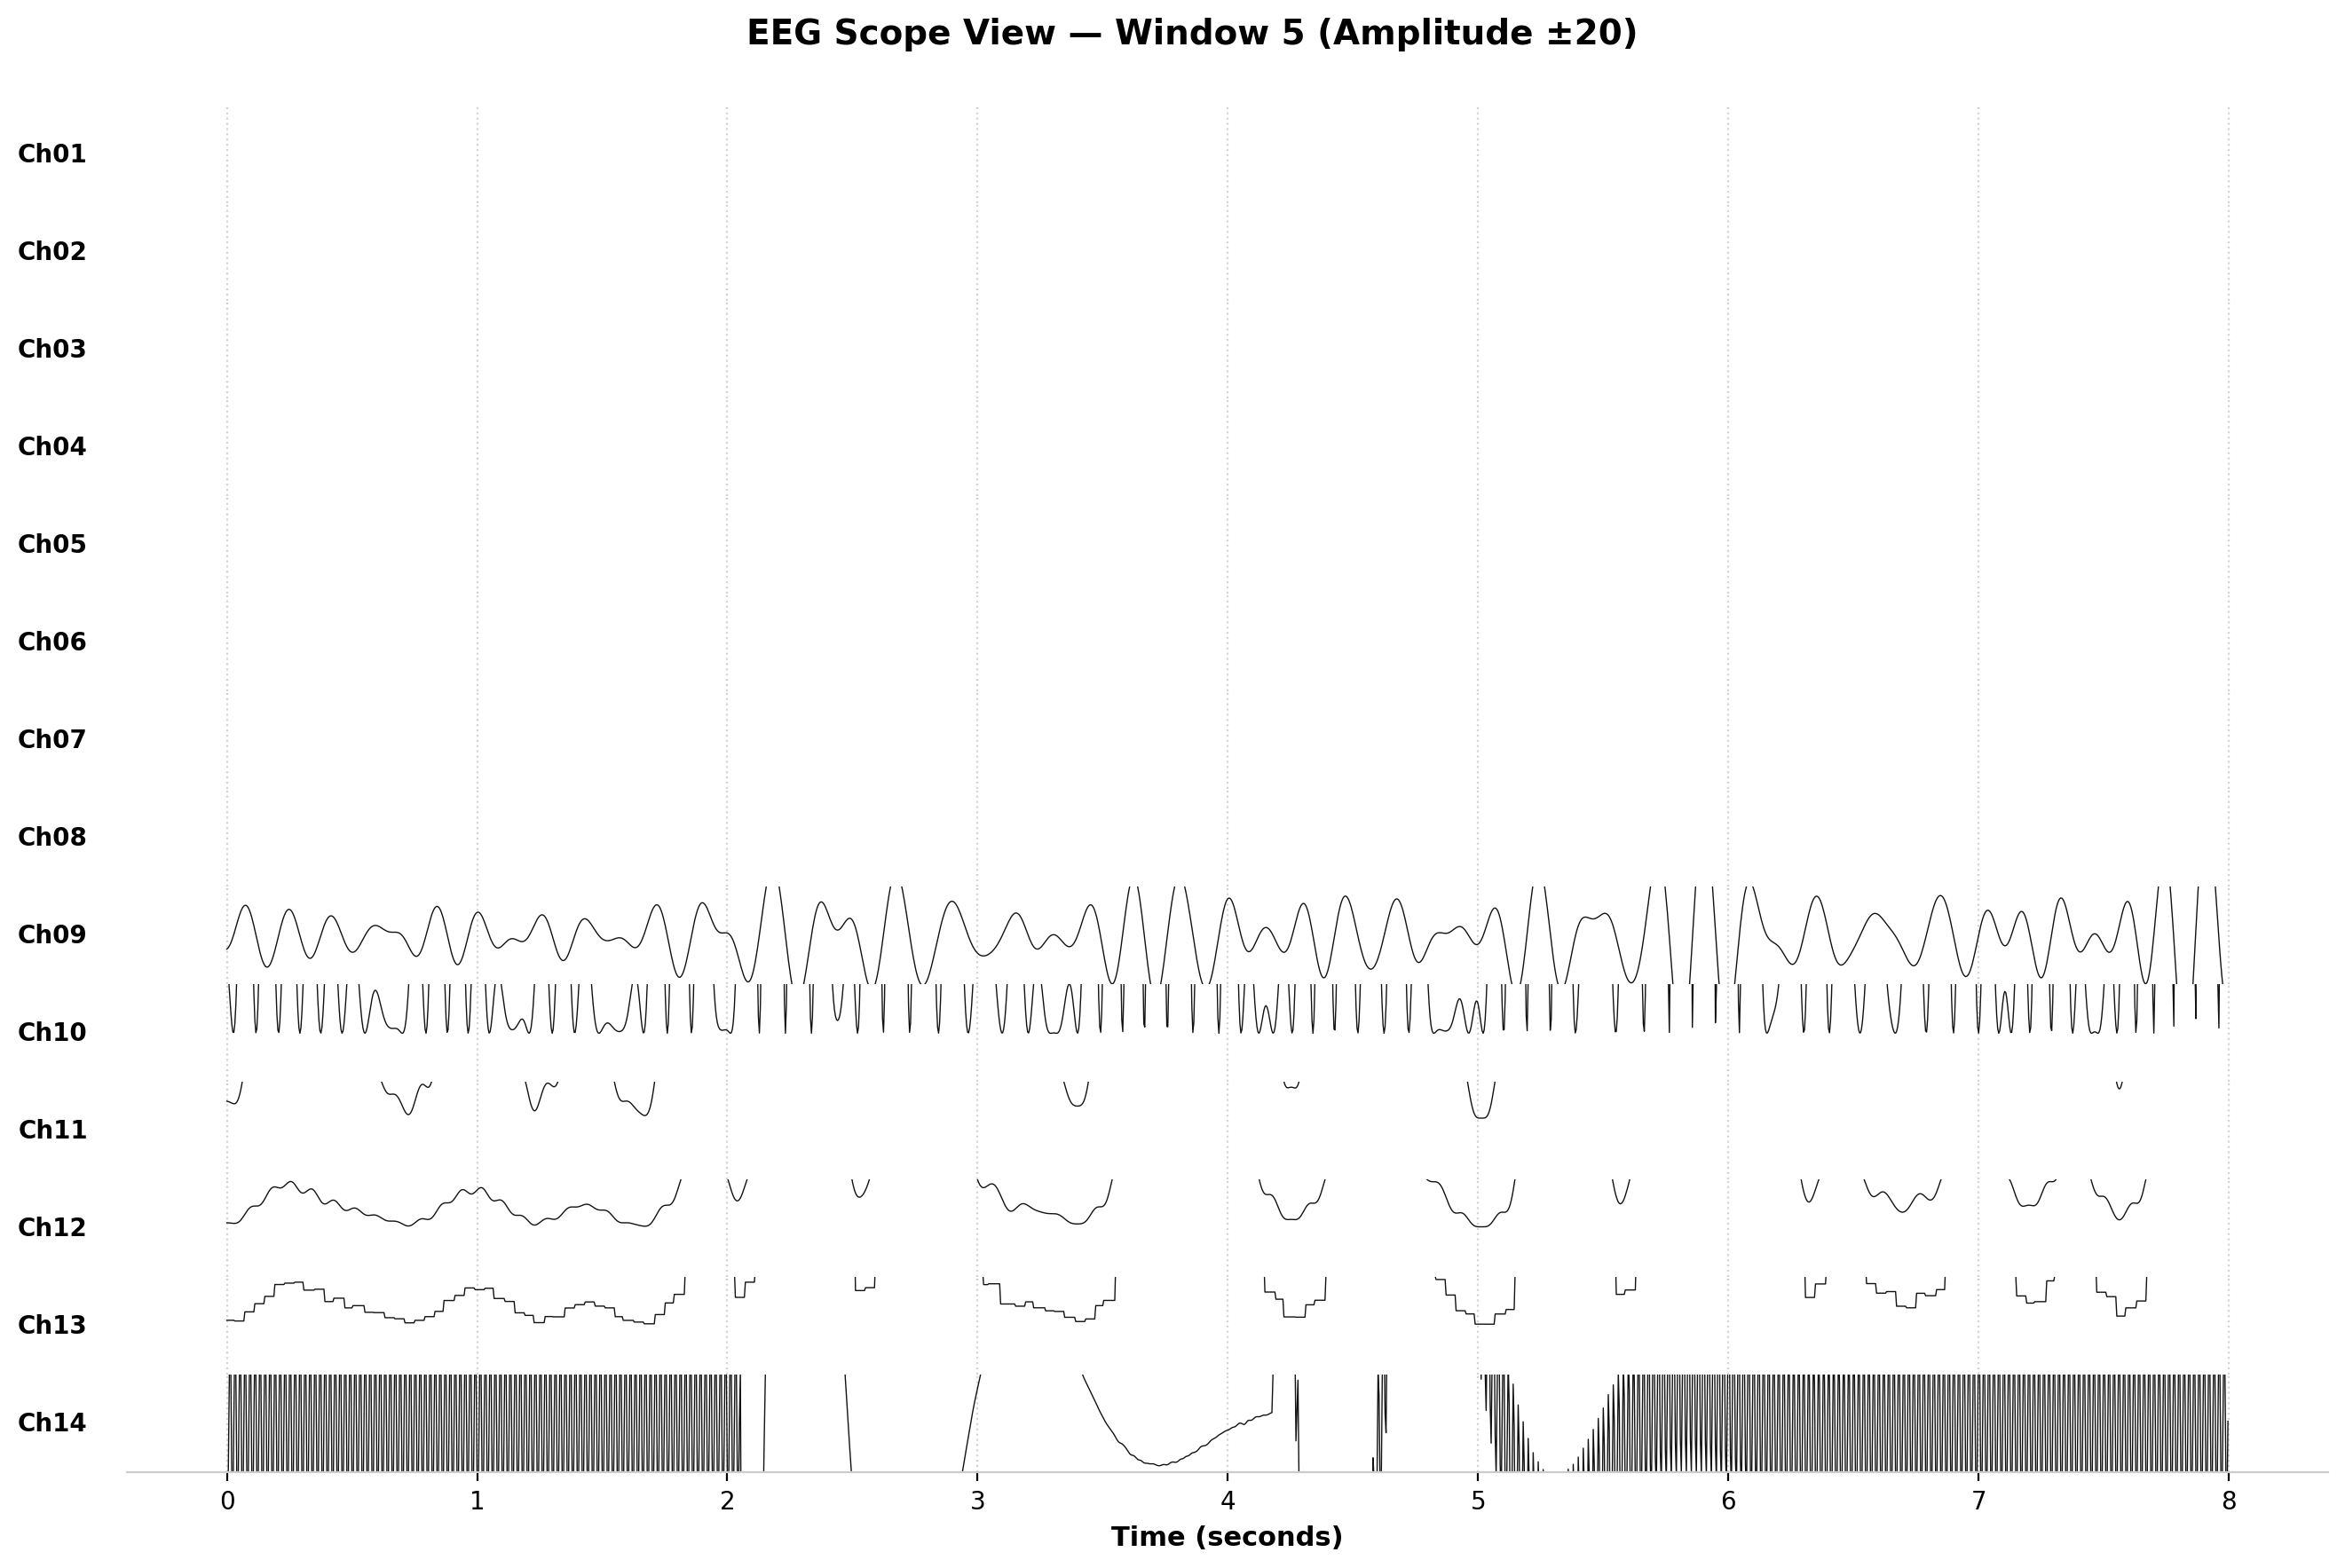

In [586]:
import numpy as np
import matplotlib.pyplot as plt

# windows: shape (4, 2250, 10)
# Example: windows = np.random.randn(4, 2250, 10)

n_windows = windows.shape[0]
n_times   = windows.shape[1]
n_channels = windows.shape[2]

AMPLITUDE_WINDOW = 20

# Time axis (assuming 250 Hz sampling)
fs = 250
time = np.arange(n_times) / fs

for w in range(n_windows):
    fig, axes = plt.subplots(n_channels, 1, figsize=(16, 10), sharex=True, dpi=200)
    
    for ch in range(n_channels):
        axes[ch].plot(time, windows[w, :, ch], color='#111111', linewidth=0.5)
        axes[ch].set_ylim(-AMPLITUDE_WINDOW, AMPLITUDE_WINDOW)
        axes[ch].set_ylabel(f"Ch{ch+1:02d}", rotation=0, labelpad=30,
                            verticalalignment='center', fontweight='bold')
        axes[ch].grid(True, linestyle=':', alpha=0.5, color='#aaaaaa')
        axes[ch].set_yticks([])
        
        for spine in ['top', 'right', 'left', 'bottom']:
            axes[ch].spines[spine].set_visible(False)

    axes[-1].spines['bottom'].set_visible(True)
    axes[-1].spines['bottom'].set_color('#cccccc')
    axes[-1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')

    plt.subplots_adjust(hspace=0.0)
    plt.suptitle(f'EEG Scope View — Window {w+1} (Amplitude ±20)', fontsize=14, fontweight='bold', y=0.93)
    plt.show()


In [587]:
# delay
small = []
for idx, df in enumerate(windows):
    df = windows[idx][1000:1500]
    small.append(df)
small = np.array(small)
small.shape

(5, 500, 14)

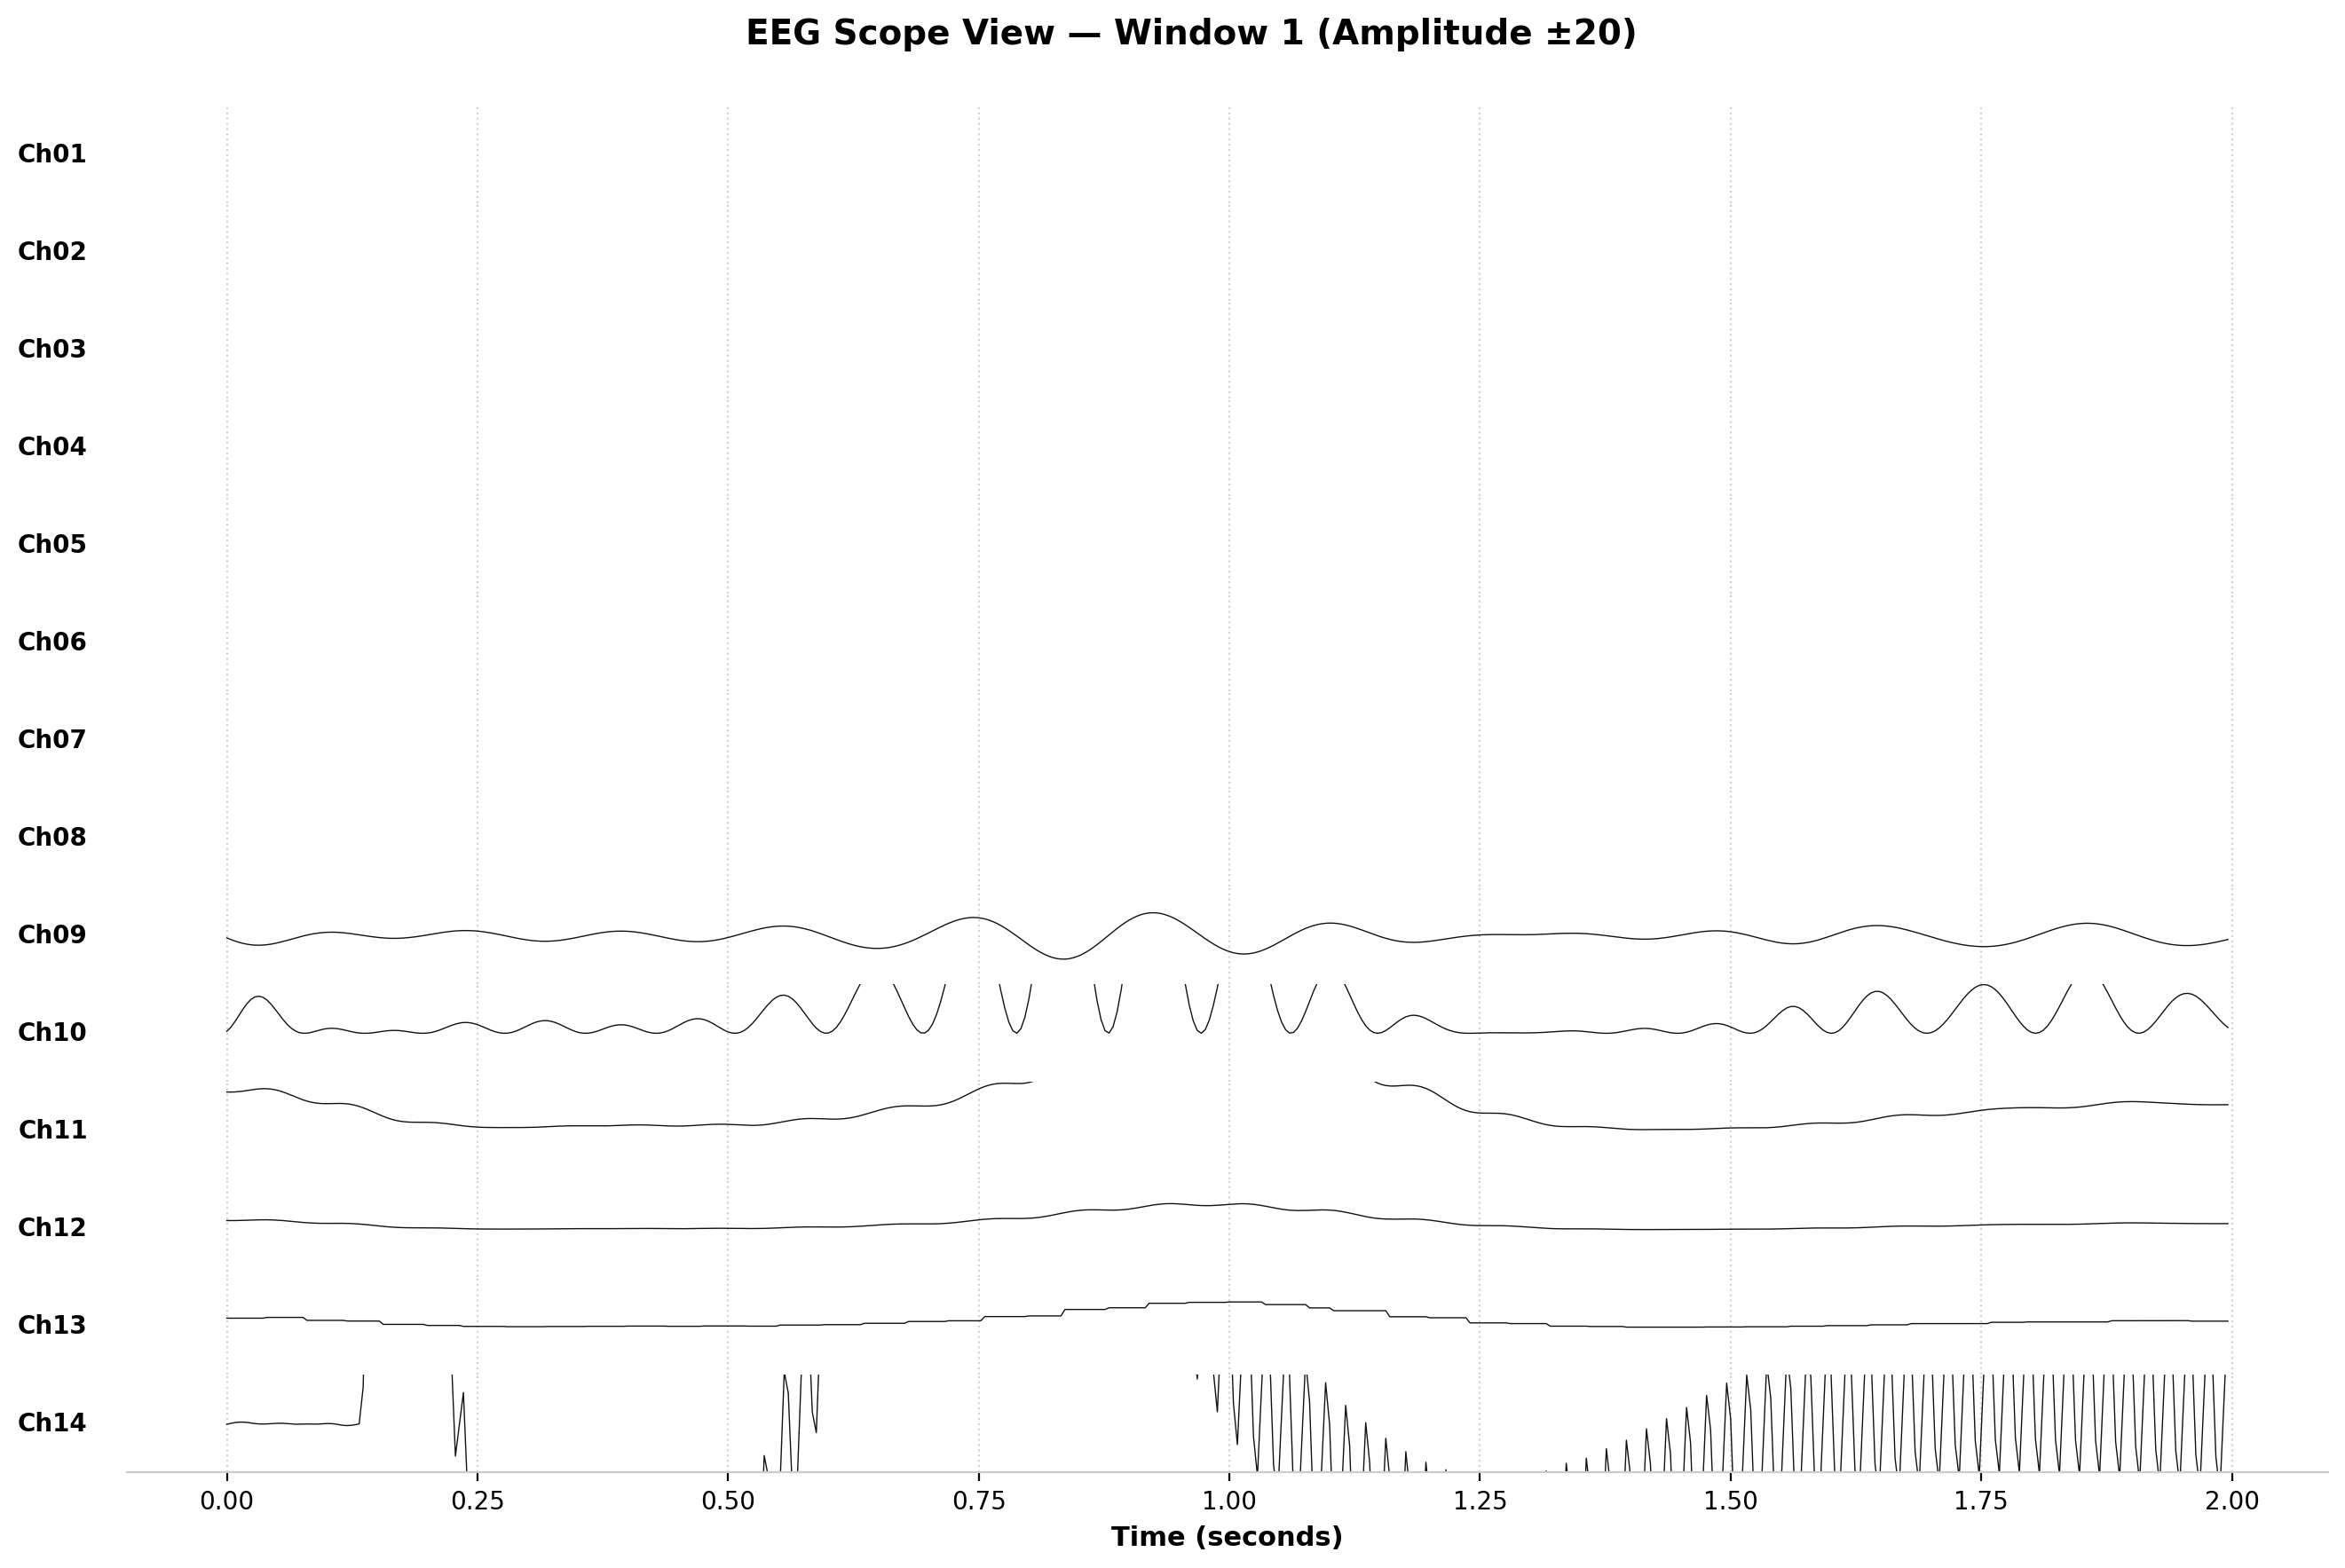

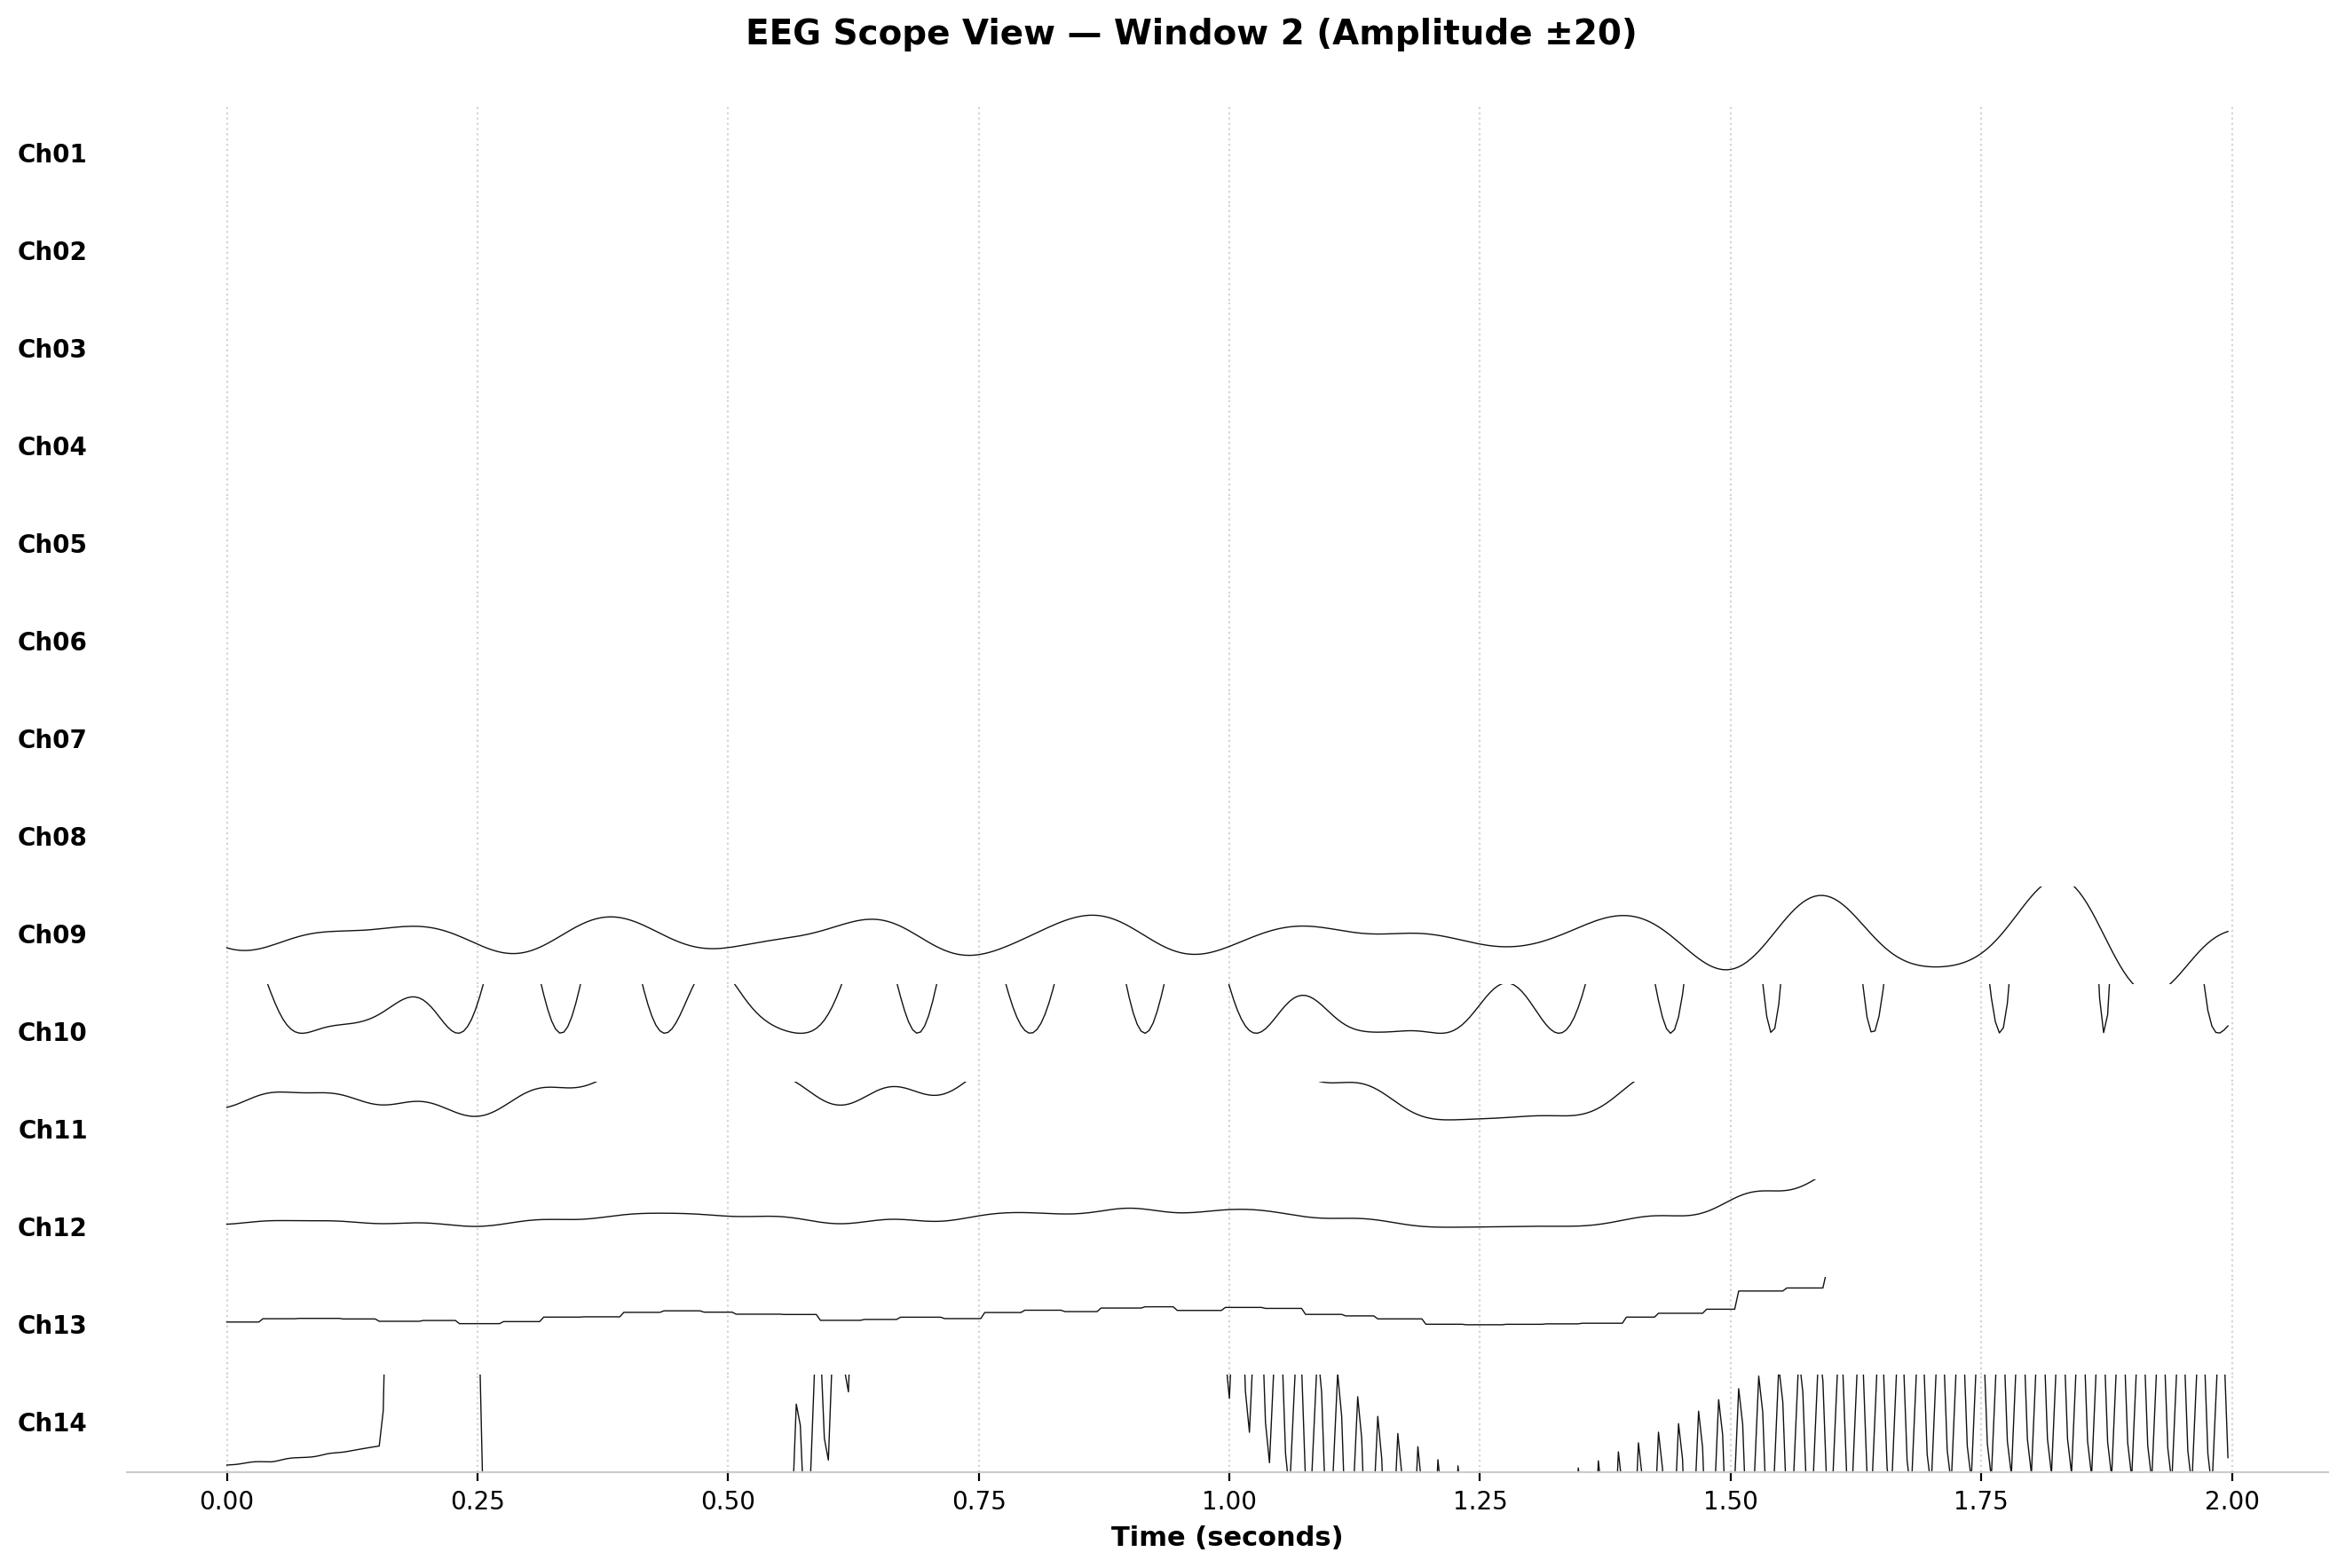

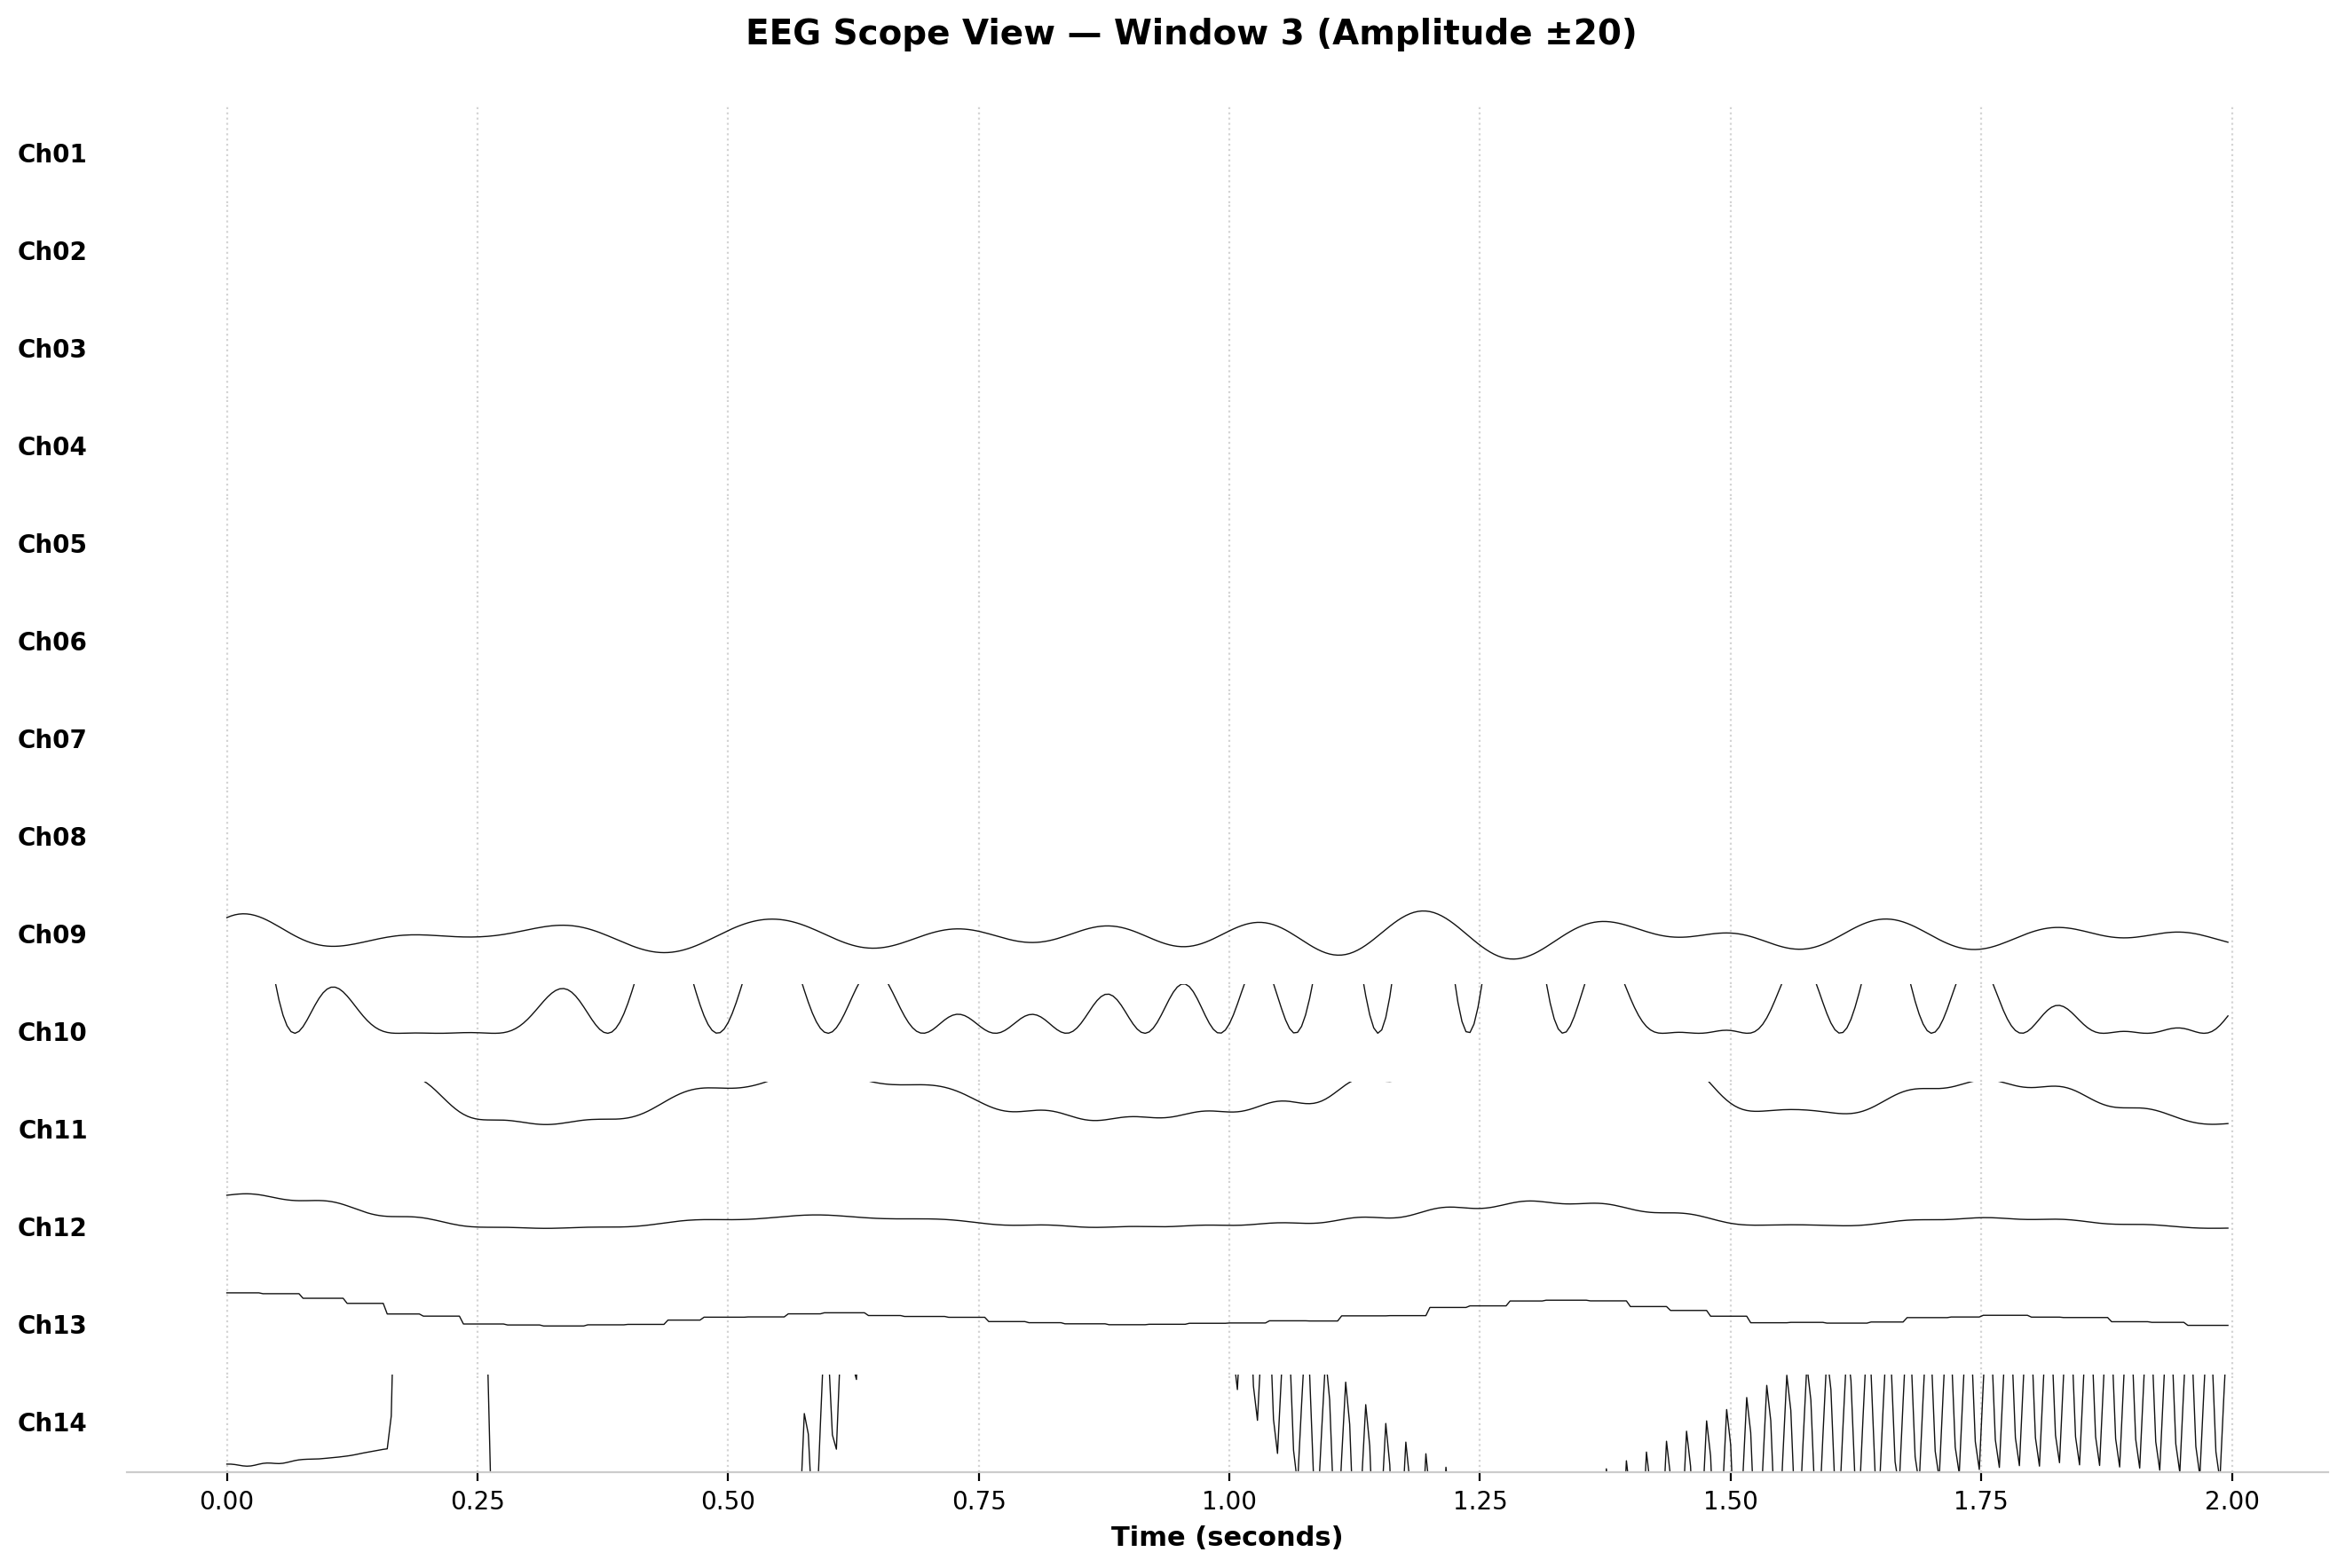

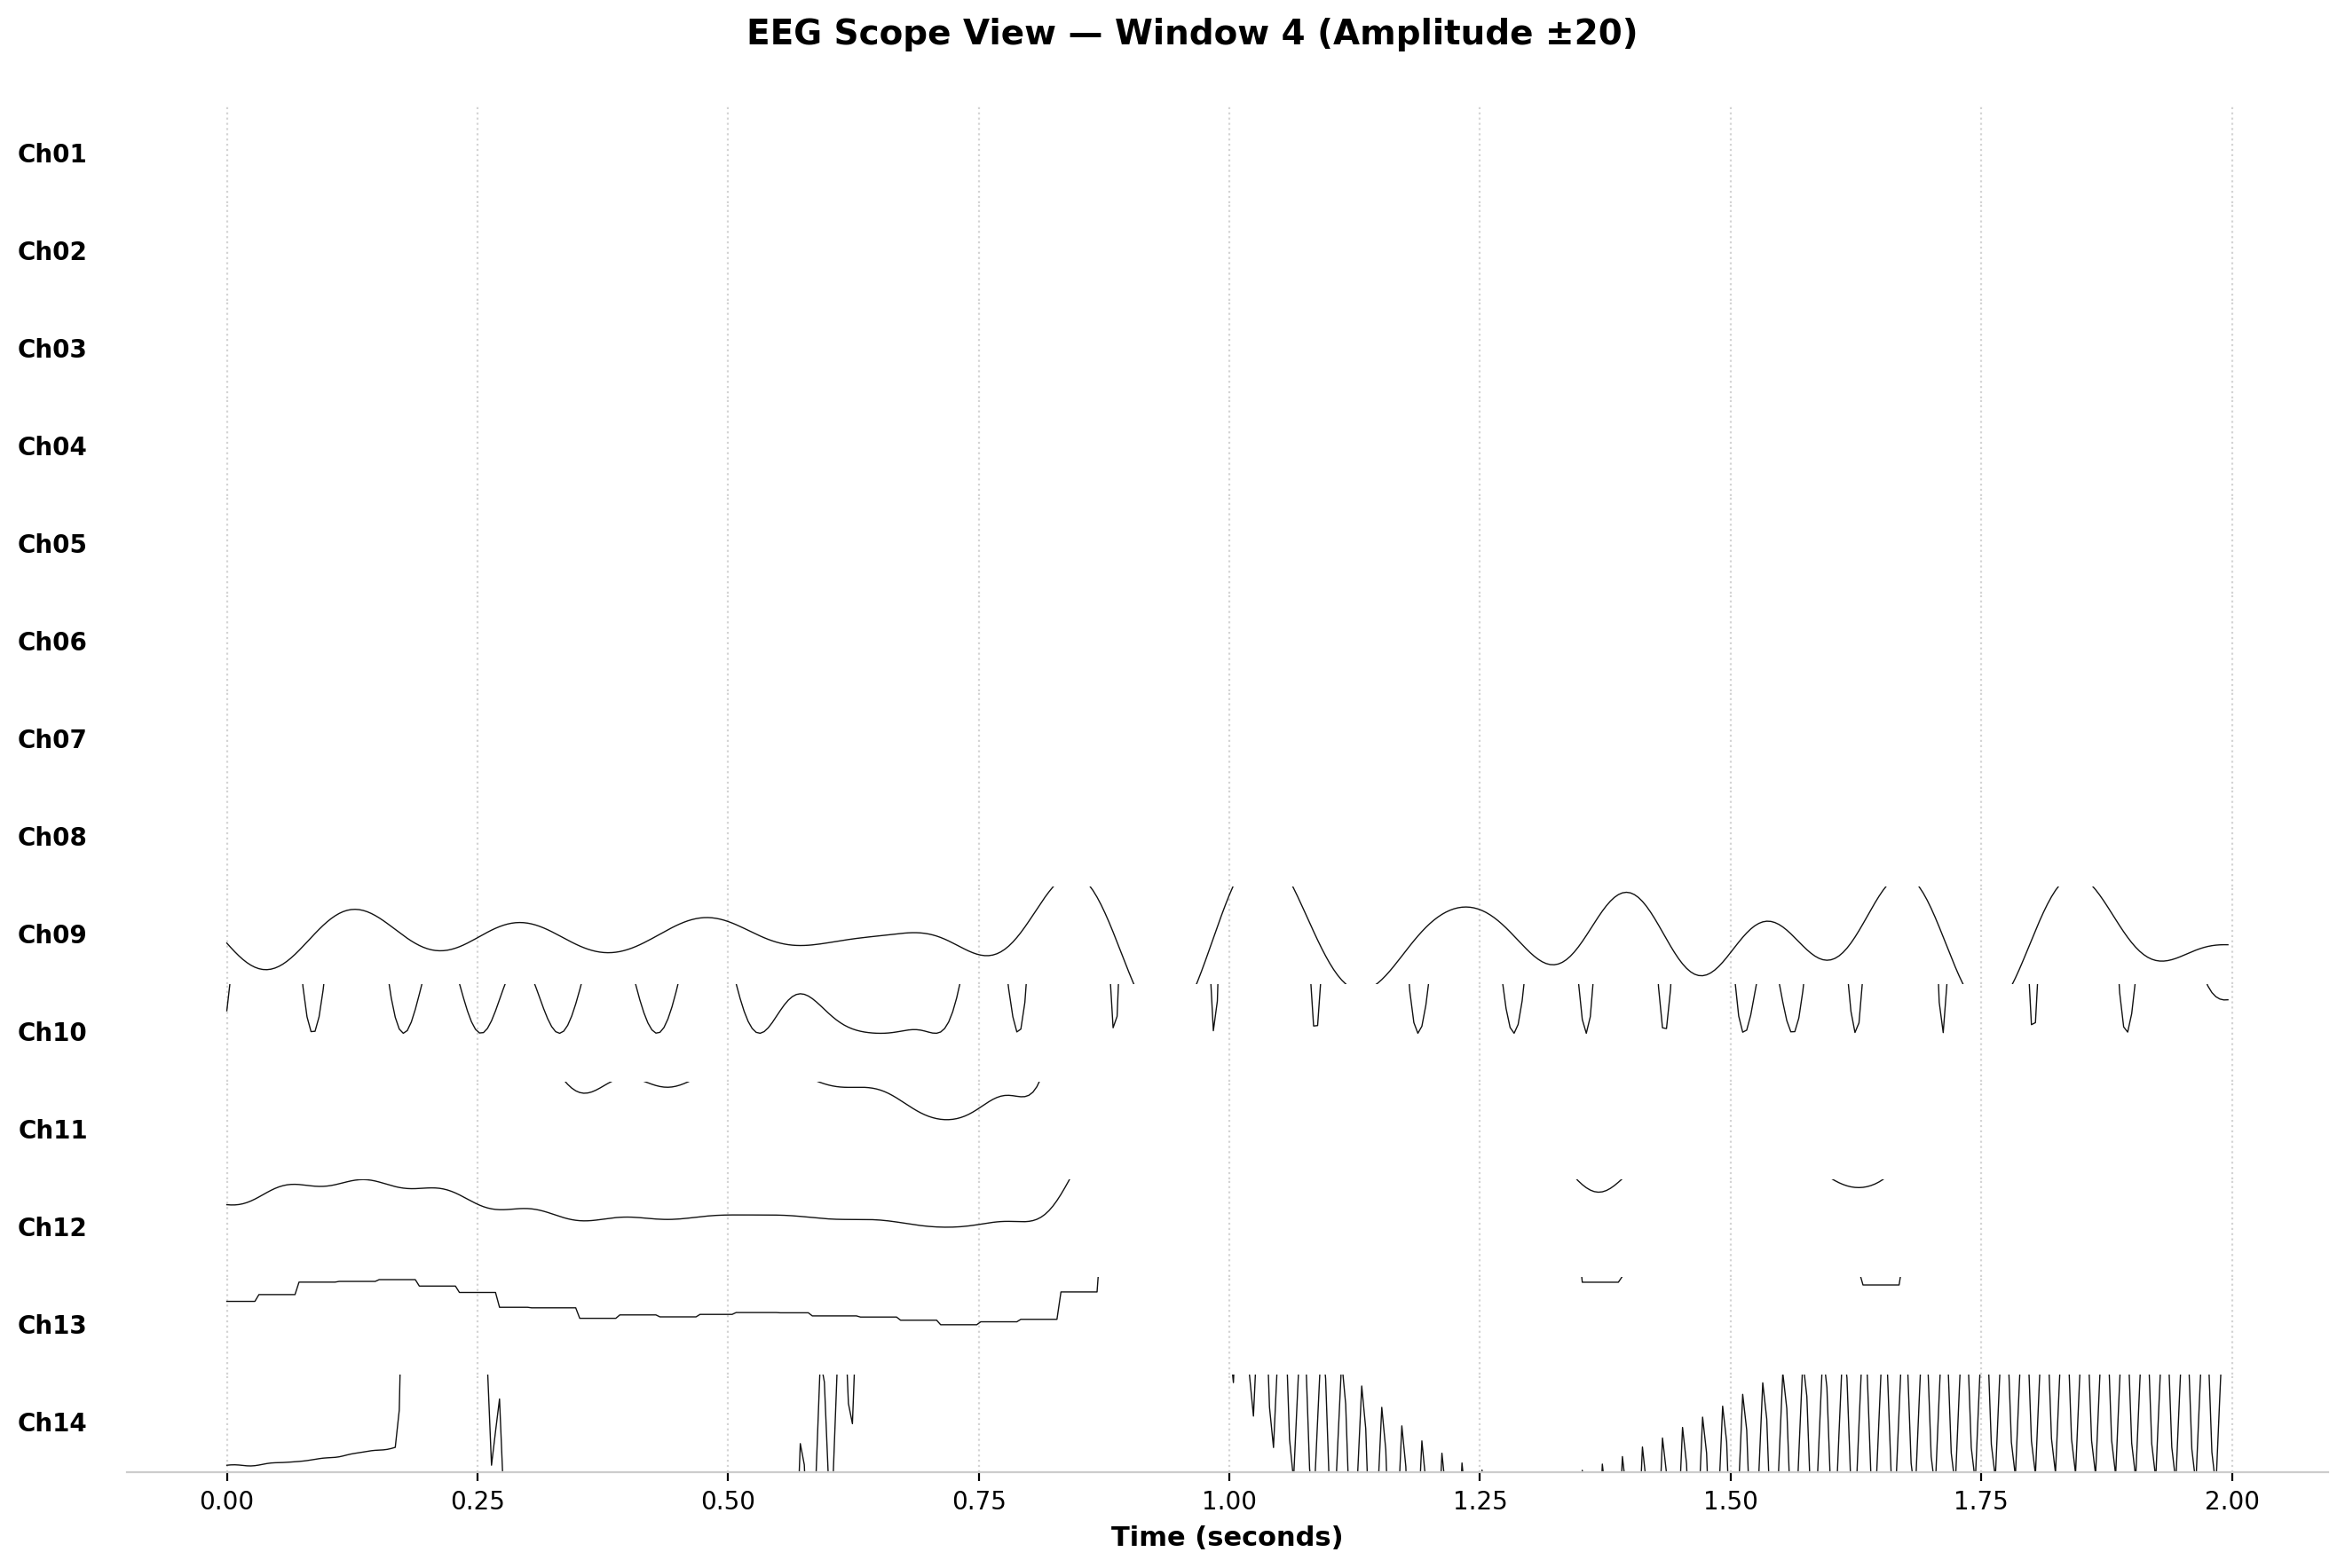

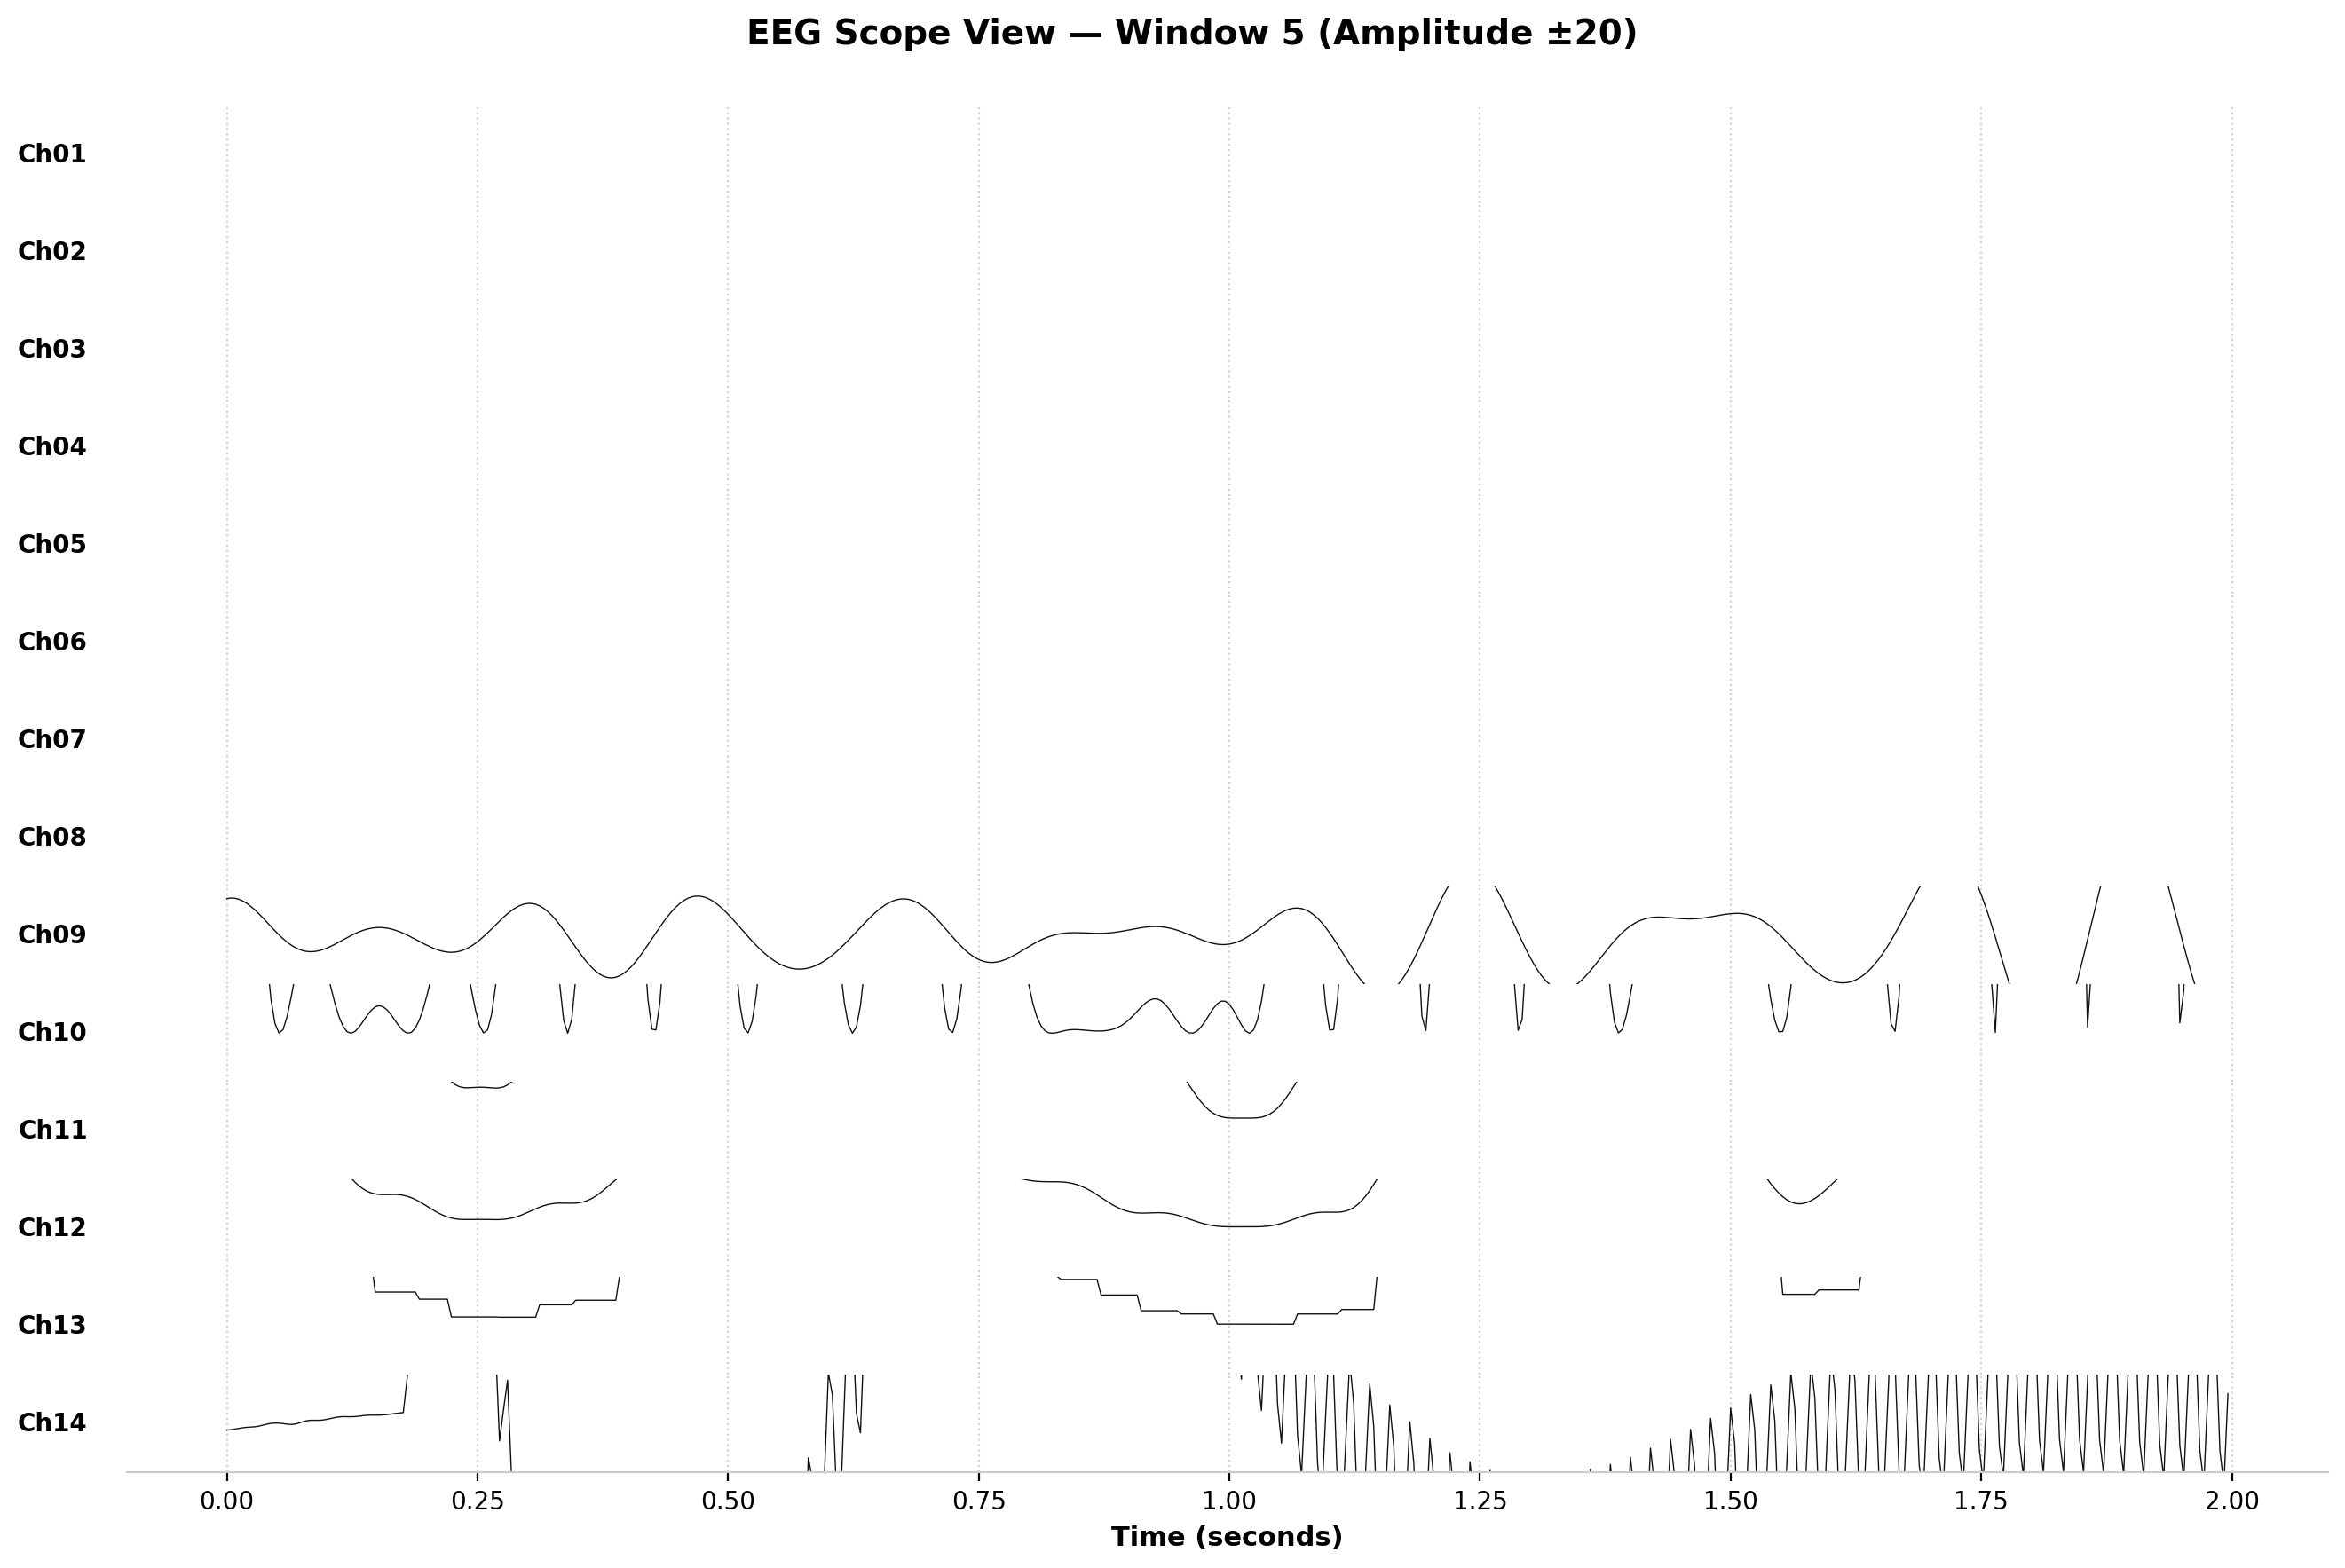

In [542]:
import numpy as np
import matplotlib.pyplot as plt

# windows: shape (4, 2250, 10)
# Example: windows = np.random.randn(4, 2250, 10)

n_windows = small.shape[0]
n_times   = small.shape[1]
n_channels = small.shape[2]

AMPLITUDE_WINDOW = 20

# Time axis (assuming 250 Hz sampling)
fs = 250
time = np.arange(n_times) / fs

for w in range(n_windows):
    fig, axes = plt.subplots(n_channels, 1, figsize=(16, 10), sharex=True, dpi=200)
    
    for ch in range(n_channels):
        axes[ch].plot(time, small[w, :, ch], color='#111111', linewidth=0.5)
        axes[ch].set_ylim(-AMPLITUDE_WINDOW, AMPLITUDE_WINDOW)
        axes[ch].set_ylabel(f"Ch{ch+1:02d}", rotation=0, labelpad=30,
                            verticalalignment='center', fontweight='bold')
        axes[ch].grid(True, linestyle=':', alpha=0.5, color='#aaaaaa')
        axes[ch].set_yticks([])
        
        for spine in ['top', 'right', 'left', 'bottom']:
            axes[ch].spines[spine].set_visible(False)

    axes[-1].spines['bottom'].set_visible(True)
    axes[-1].spines['bottom'].set_color('#cccccc')
    axes[-1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')

    plt.subplots_adjust(hspace=0.0)
    plt.suptitle(f'EEG Scope View — Window {w+1} (Amplitude ±20)', fontsize=14, fontweight='bold', y=0.93)
    plt.show()
